<img src="https://www.javeriana.edu.co/recursosdb/20125/5571273/escudo-circular.png" alt="Escudo Javeriana" style="float:left;">
<h1>Pontificia Universidad Javeriana</h1>

<h2>Modelado CRISP-DM — Predicción de Cultivos</h2>

### Integrantes:

* 

## Metodología CRISP-DM aplicada a la predicción de aptitud de cultivos

Este cuaderno documenta la aplicación paso a paso del marco **CRISP-DM** para modelar la clasificación de cultivos agrícolas en el departamento de Cundinamarca, Colombia. El dataset proviene de la vista minable construida a partir de datos de satélite (Sentinel-2), clima (IDEAM/CHIRPS), suelo (SoilGrids/IGAC), topografía (DEM) y evidencia agrícola (EVA, UPRA, SIPRA).

**Variable objetivo:** `cultivo_id` — **14 clases** con etiquetado jerárquico de 3 niveles:
- **L1** Monitoreo UPRA (`fuente='monitoreo'`, `confianza=1.0`) — ground truth espacial de Papa y Arroz.
- **L2** EVA municipal (`fuente='eva_municipal'`, `confianza=0.3-0.7`) — cultivo dominante del municipio-semestre, ponderado por `area_cosechada/area_agricola`.
- **L3** No_apto proxy (`fuente='noapto_proxy'`, `confianza=0.4`) — asignado si ≥3 capas SIPRA reportan "No apta" o NDVI_max<0.15.

Catálogo de 14 clases: *Papa, Cana_Panelera, Cafe, Maiz, Platano, Mango, Frijol, Cacao, Arveja, Palma, Banano, Naranja, Otros_cultivos, No_apto*.

**Decisión de diseño clave**: el modelo se entrena con `sample_weight = confianza` para que los L1 dominen el ajuste sin perder cobertura de los L2/L3. La validación usa **`GroupKFold` por `cod_mun`** para evitar fuga espacial (pixeles vecinos del mismo municipio no aparecen en train+test).


---

# 1. Comprensión del Negocio

### 1.1 Objetivo del proyecto
- **Predecir el tipo de cultivo más apto** para cada píxel de 50m × 50m en Cundinamarca usando variables ambientales, edáficas y climáticas.
- **Identificar patrones** entre las condiciones del terreno y los cultivos establecidos.
- **Construir un modelo de clasificación multiclase** interpretable y de alto desempeño que pueda servir como herramienta de apoyo a la planificación agrícola.

### 1.2 Contexto y alcance
- La seguridad alimentaria y la optimización del uso del suelo son prioritarias para Colombia. Conocer qué cultivos son más viables en cada zona permite mejorar la productividad y reducir el riesgo de pérdida de cosechas.
- El dataset integra múltiples fuentes: imágenes satelitales Sentinel-2, datos climáticos IDEAM/CHIRPS, propiedades de suelo SoilGrids/IGAC y modelos digitales de elevación.
- La granularidad es **un registro por píxel-semestre** para 14 clases de cultivo.

### 1.3 Criterios de éxito
- **F1-score macro** ≥ 0.45 en datos de prueba (14 clases con desbalance y etiquetas ruidosas en L2/L3 hace este umbral más realista que el 0.60 anterior de 7 clases).
- **ROC-AUC macro** ≥ 0.80 (one-vs-rest).
- Validación **espacial** (GroupKFold por municipio) para verificar que el modelo generaliza a zonas no vistas.
- Análisis diferenciado de métricas por nivel de confianza (L1 vs L2 vs L3).


---

# 2. Comprensión de los Datos

### Plan de Exploración

En esta fase exploraremos el dataset para:
1. **Validar la estructura**: Confirmar dimensiones y variables disponibles
2. **Evaluar calidad**: Identificar valores faltantes, duplicados y outliers
3. **Analizar distribuciones**: Revisar balance de clases y distribuciones de variables numéricas
4. **Detectar patrones**: Explorar relaciones entre variables predictoras y la variable objetivo
5. **Identificar transformaciones necesarias**: Determinar si requieren escalamiento, codificación o ingeniería de features

### 2.1 Importar Librerías

In [50]:
# Instalacion de dependencias del cuaderno
# Cubre: numerico, viz, ML clasico, XGBoost, balanceo, optimizacion bayesiana,
# Jupyter helpers y lectura de parquet.
#
# Si usas uv: uv pip install --active <paquetes>   (--active fuerza al env Anaconda)
# Si usas pip: ejecuta esta celda una vez por entorno.

%pip install -q "numpy>=1.24" "pandas>=2.0" "pyarrow>=14" "matplotlib>=3.8" "seaborn>=0.13" "scikit-learn>=1.4" "xgboost>=2.0" "imbalanced-learn>=0.12" "optuna>=3.6" "optuna-integration[sklearn]>=3.6" "nbformat>=5.9" "ipykernel>=6.29" "tqdm>=4.66"

print("Dependencias instaladas. Reinicia el kernel si se actualizo alguna libreria critica.")


Note: you may need to restart the kernel to use updated packages.
Dependencias instaladas. Reinicia el kernel si se actualizo alguna libreria critica.


In [51]:
# Suppression de warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Stdlib
import os
import json
import collections
import subprocess
from pathlib import Path

# Numericas / DataFrames
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

%matplotlib inline
mpl.style.use('ggplot')
sns.set_style("whitegrid")
pylab.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.figsize"] = (12, 6)

# Preprocesamiento
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder,
    LabelEncoder, Normalizer, scale, label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBClassifier as _XGBClassifier_base
from sklearn.preprocessing import LabelEncoder as _LE_inner

# Seleccion / validacion / split
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score,
    GroupShuffleSplit, GroupKFold, StratifiedGroupKFold
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFECV

# Metricas
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, roc_curve, auc
)

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Optimizacion bayesiana
import optuna
import optuna.distributions as odist
from optuna.integration import OptunaSearchCV
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuracion
np.random.seed(42)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerias importadas correctamente.")


Librerias importadas correctamente.


In [52]:
# --- Verificar disponibilidad de GPU para XGBoost ---
import xgboost as xgb

try:
    gpu_available = xgb.build_info().get('USE_CUDA', False)
    # Intentar crear una pequeña matriz DMatrix en GPU
    test_data = np.random.rand(100, 10).astype(np.float32)
    test_labels = np.random.randint(0, 3, 100)
    dtest = xgb.DMatrix(test_data, label=test_labels)
    
    # Verificar si CUDA está disponible
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    gpu_present = result.returncode == 0
    
    if gpu_present:
        XGB_DEVICE = 'cuda'
        XGB_TREE_METHOD = 'hist'
        print(f"✅ GPU detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
    else:
        XGB_DEVICE = 'cpu'
        XGB_TREE_METHOD = 'hist'
        print(f"⚠️ GPU no detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
except Exception as e:
    XGB_DEVICE = 'cpu'
    XGB_TREE_METHOD = 'hist'
    print(f"⚠️ Error verificando GPU: {e}. Usando CPU.")

XGB_N_JOBS = 1 if XGB_DEVICE == "cuda" else -1
CV_N_JOBS  = 1 if XGB_DEVICE == "cuda" else -1  # n_jobs en GridSearchCV
print(f"Configuracion XGBoost: device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}', n_jobs={XGB_N_JOBS}")
if XGB_DEVICE == "cuda":
    print("GPU activa: GridSearchCV corre serial (n_jobs=1); XGBoost paralelo internamente en CUDA.")
else:
    print("CPU: GridSearchCV paralelo en todos los cores.")


# ==================================================================
# XGBClassifierRemap: wrapper que tolera folds con clases ausentes
# ==================================================================
# XGBoost valida np.unique(y) == np.arange(K) en cada fit().
# En CV con GroupKFold/StratifiedGroupKFold, si una clase rara queda
# fuera del training de un fold, las labels son no-contiguas y XGBoost
# lanza "Invalid classes inferred". Este wrapper aplica un LabelEncoder
# interno por fit que renumera a [0..K_fold-1] contiguo, y revierte en
# predict()/predict_proba() para que sklearn vea las clases originales.
from xgboost import XGBClassifier as _XGBClassifier_base
from sklearn.preprocessing import LabelEncoder as _LE_inner


class XGBClassifierRemap(_XGBClassifier_base):
    """XGBClassifier que remapea labels a contiguos por fit, transparente al caller."""

    def fit(self, X, y, **kwargs):
        self._le_remap = _LE_inner()
        y_inner = self._le_remap.fit_transform(y)
        # Pisar num_class si estaba seteado: ahora es el K_fold real
        try:
            self.set_params(num_class=len(self._le_remap.classes_))
        except Exception:
            pass
        # Remapear y_eval en sample_weight_eval_set / eval_set
        if 'eval_set' in kwargs and kwargs['eval_set'] is not None:
            kwargs['eval_set'] = [
                (Xe, self._le_remap.transform(ye)) for (Xe, ye) in kwargs['eval_set']
            ]
        return super().fit(X, y_inner, **kwargs)

    def predict(self, X, **kwargs):
        preds_inner = super().predict(X, **kwargs)
        return self._le_remap.inverse_transform(preds_inner.astype(int))

    def predict_proba(self, X, **kwargs):
        # proba interno en orden de self._le_remap.classes_; respetamos ese orden.
        # La clase expone classes_ = self._le_remap.classes_, asi que sklearn alinea bien.
        return super().predict_proba(X, **kwargs)

    @property
    def classes_(self):
        if hasattr(self, '_le_remap'):
            return self._le_remap.classes_
        return getattr(super(), 'classes_', None)


print("XGBClassifierRemap definido (tolera folds con clases ausentes en CV).")


✅ GPU detectada. XGBoost usará device='cuda', tree_method='hist'
Configuracion XGBoost: device='cuda', tree_method='hist', n_jobs=1
GPU activa: GridSearchCV corre serial (n_jobs=1); XGBoost paralelo internamente en CUDA.
XGBClassifierRemap definido (tolera folds con clases ausentes en CV).


### 2.2 Funciones Auxiliares

In [53]:
def plot_distribution(df, var, target, **kwargs):
    """Distribución KDE de una variable por clase objetivo."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    facet = sns.FacetGrid(df, hue=target, aspect=4, row=row, col=col)
    facet.map(sns.kdeplot, var, fill=True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()
    plt.title(f'Distribución de {var} por {target}')

def plot_categories(df, cat, target, **kwargs):
    """Gráfico de barras de una variable categórica vs target."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    order = sorted(df[cat].unique())
    facet = sns.FacetGrid(df, row=row, col=col)
    facet.map(sns.barplot, cat, target, order=order)
    facet.add_legend()

def plot_correlation_map(df, figsize=(16, 14)):
    """Mapa de calor de correlaciones entre variables numéricas."""
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        raise ValueError("No hay columnas numéricas.")
    corr = num.corr()
    _, ax = plt.subplots(figsize=figsize)
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(
        corr, cmap=cmap, square=True,
        cbar_kws={"shrink": 0.9}, ax=ax,
        annot=True, annot_kws={"fontsize": 7}, fmt=".2f"
    )
    plt.title('Mapa de Correlaciones')
    plt.tight_layout()

def plot_class_balance(y, title='Distribución de Clases'):
    """Visualizar el balance de clases del target."""
    counts = pd.Series(y).value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(counts)))
    for i, (val, name) in enumerate(zip(counts.values, counts.index)):
        ax.text(i, val + counts.max()*0.01, f'{val:,}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Número de registros')
    ax.set_xlabel('Clase (cultivo_id)')
    plt.tight_layout()

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


### 2.3 Cargar los Datos

In [54]:
# --- Configuración de rutas locales ---
# El notebook se ejecuta desde `modelado/` — los datos están en `../vista_minable/`.
import os
from pathlib import Path

# Directorio raíz del proyecto (sube un nivel desde modelado/)
PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'modelado' \
                                        else Path(os.getcwd())
DATA_DIR = PROJECT_ROOT / 'vista_minable'

print(f"Directorio del proyecto: {PROJECT_ROOT}")
print(f"Directorio de datos:     {DATA_DIR}")
assert DATA_DIR.exists(), f"No se encontró {DATA_DIR}. Ejecuta 04_construir_vista_minable primero."


Directorio del proyecto: d:\trabajo\agroplus
Directorio de datos:     d:\trabajo\agroplus\vista_minable


In [55]:
# Cargar la vista minable
DATA_PATH = DATA_DIR / 'vista_minable_full.parquet'
df_raw = pd.read_parquet(DATA_PATH)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"\nDistribucion por fuente (L1/L2/L3):")
print(df_raw['fuente'].value_counts())
print(f"\nDistribucion de confianza:")
print(df_raw['confianza'].describe())


Dataset cargado: 5,415,961 filas x 69 columnas

Distribucion por fuente (L1/L2/L3):
fuente
eva_municipal    3390312
noapto_proxy     1459620
monitoreo         566029
Name: count, dtype: int64

Distribucion de confianza:
count   5415961.0000
mean          0.6505
std           0.1767
min           0.4000
25%           0.4000
50%           0.7000
75%           0.7000
max           1.0000
Name: confianza, dtype: float64


In [56]:
# Cargar catalogo de cultivos (mapeo nombre -> cultivo_id)
CATALOGO_PATH = DATA_DIR / 'catalogo_cultivos.json'
with open(CATALOGO_PATH, 'r', encoding='utf-8') as f:
    catalogo = json.load(f)

# Catalogo ordenado por id (MODEL_CLASSES tiene el orden estable del proyecto)
inv_catalogo = {v: k for k, v in catalogo.items()}
print(f"Catalogo de {len(catalogo)} clases:")
for i in sorted(inv_catalogo):
    print(f"  {i:2d}: {inv_catalogo[i]}")


Catalogo de 14 clases:
   0: Papa
   1: Cana_Panelera
   2: Cafe
   3: Maiz
   4: Platano
   5: Mango
   6: Frijol
   7: Cacao
   8: Arveja
   9: Palma
  10: Banano
  11: Naranja
  12: Otros_cultivos
  13: No_apto


In [57]:
# Vista general del DataFrame
df_raw.head(10)

,pixel_id,x,y,semestre,cod_mun,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,...,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo,cultivo_id,confianza,fuente,rendimiento_tha,prob_Papa,prob_Cana_Panelera,prob_Cafe,prob_Maiz,prob_Platano,prob_Mango,prob_Frijol,prob_Cacao,prob_Arveja,prob_Palma,prob_Banano,prob_Naranja,prob_Otros_cultivos,prob_No_apto
0,0,1107022.7366,1137622.5453,2020A,0,3009.6982,12.5241,20.0455,5.5000,97.5000,53.2000,25.8000,10.6000,29.0000,30.0000,40.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,0.6507,-0.8811,0.4730,-0.6050,-0.0890,-1.3440,71.6516,372.1031,...,0.0111,0.2292,0.1733,0.3359,0.5101,0.1037,1.2550,-1.4321,0.7516,96.3826,3.0764,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,1,1060221.1597,1137572.5366,2020A,0,2174.9927,13.8300,19.6552,5.4000,75.1000,46.8000,23.7000,9.4000,40.0000,31.0000,28.0000,3.0000,1.0000,1.0000,1.0000,3.0000,2.0000,0.5284,0.8365,-0.5480,3.6222,4.3000,3.0504,71.6516,730.4546,...,-0.1860,-0.1262,0.0495,0.4130,0.5531,0.1688,1.2496,-2.0888,0.8010,107.0441,4.8579,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,2,1062471.2355,1137572.5366,2020A,0,2325.3787,11.0770,20.5380,5.3000,83.6000,39.5000,25.7000,9.7000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.5255,0.9380,0.3466,2.7806,3.4366,2.2582,71.6516,733.9651,...,-0.0288,-0.0057,0.0199,0.3019,0.3325,0.0317,1.1784,-2.0776,0.6604,101.1445,5.2322,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,4,1071271.5320,1137572.5366,2020A,0,2059.6421,0.6440,23.8345,5.6000,50.9000,42.6000,24.4000,10.3000,33.0000,31.0000,35.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4658,0.9470,-0.3213,4.4441,5.0226,4.0970,71.6516,730.7438,...,-0.0889,-0.0517,0.0355,0.4066,0.4594,0.0342,0.9256,-1.9294,0.7346,113.9380,5.4381,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
4,5,1071821.5506,1137572.5366,2020A,0,2060.9927,1.5970,21.4907,5.4000,64.8000,44.0000,22.6000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4747,0.9181,0.3964,4.3788,4.9520,4.0370,71.6516,731.0130,...,-0.2170,-0.1662,0.0425,0.5185,0.5747,0.0646,0.9151,-1.9126,0.8185,127.2868,5.4874,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
5,6,1071921.5539,1137572.5366,2020A,0,2063.5684,1.5206,19.8580,5.4000,64.4000,44.2000,22.3000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4714,0.8045,-0.5939,4.3658,4.9380,4.0235,71.6516,731.0619,...,-0.1939,-0.1667,0.0278,0.4860,0.5175,0.0449,0.9145,-1.9095,0.7764,126.7796,5.4926,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
6,7,1077771.7511,1137572.5366,2020A,0,2232.4365,21.7495,24.3270,5.5000,92.5000,43.0000,22.6000,10.3000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.5472,0.7914,0.6113,2.4908,2.9984,2.1302,71.6516,690.0074,...,-1666.7773,-0.2338,3726.2832,-1666.0785,0.5608,3726.5959,0.8681,-1.8122,0.8659,-299853.5000,5.8126,No_apto,13,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
7,8,1090322.1739,1137572.5366,2020A,0,2936.6338,56.5498,20.3787,5.5000,99.0000,50.5000,29.2000,9.4000,32.0000,34.0000,32.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2

In [58]:
# Información general de tipos y nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5415961 entries, 0 to 5415960
Data columns (total 69 columns):
 #   Column               Dtype  
---  ------               -----  
 0   pixel_id             int64  
 1   x                    float64
 2   y                    float64
 3   semestre             str    
 4   cod_mun              int32  
 5   elevacion            float32
 6   pendiente            float32
 7   twi                  float32
 8   sg_phh2o             float32
 9   sg_soc               float32
 10  sg_nitrogen          float32
 11  sg_cec               float32
 12  sg_bdod              float32
 13  sg_clay              float32
 14  sg_sand              float32
 15  sg_silt              float32
 16  igac_fertilidad      float32
 17  igac_fosforo         float32
 18  igac_ph              float32
 19  igac_potasio         float32
 20  igac_vocacion        float32
 21  piso_termico         float32
 22  indice_fertilidad    float32
 23  aspecto_sin          float32
 24  aspecto_c

In [59]:
# Descripción estadística de variables numéricas
df_raw.describe()

,pixel_id,x,y,cod_mun,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,...,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo_id,confianza,rendimiento_tha,prob_Papa,prob_Cana_Panelera,prob_Cafe,prob_Maiz,prob_Platano,prob_Mango,prob_Frijol,prob_Cacao,prob_Arveja,prob_Palma,prob_Banano,prob_Naranja,prob_Otros_cultivos,prob_No_apto
count,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5368075.0000,5368075.0000,5368075.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5149645.0000,5415961.0000,5415961.0000,5415961.0000,5415853.0000,5415853.0000,5415853.0000,5415853.0000,5415961.0000,5384333.0000,...,5384333.0000,5415961.0000,5384327.0000,5384327.0000,5415961.0000,5384333.0000,5384333.0000,5415961.0000,5415853.0000,5415961.0000,5384333.0000,5415961.0000,5415853.0000,5415961.0000,5415961.0000,3956341.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000
mean,2930006.4243,1013528.6411,1033170.3140,21859.2316,2509.6111,15.4834,5.6257,5.5019,77.5305,49.2734,27.8027,10.2892,31.5189,34.1700,32.9227,2.6083,1.0656,1.3179,1.2976,2.5863,2.1145,0.6008,-0.0399,-0.1339,-0.9912,0.5244,-2.4133,79.2165,719.4253,-2612.7708,...,0.4619,3367.1272,-2613.9019,-0.0439,3367.5291,-2612.9224,0.4614,3367.1294,2.9378,-0.0076,0.7043,-472913.2500,5.2694,5.5894,0.6505,17.1642,0.3979,0.0189,0.0292,0.0468,0.0090,0.0022,0.0173,0.0045,0.0315,0.0127,0.0032,0.0028,0.1544,0.2695
std,1704823.1421,39593.8583,45738.3810,8677.1241,740.3149,13.8025,5.9574,0.3944,19.6124,8.6775,4.6189,1.2154,3.8513,5.3016,3.5481,1.0593,0.3788,0.6193,0.5397,2.9011,0.5944,0.1293,0.7203,0.6790,6.7555,7.0812,6.4216,7.3612,317.1861,2093.5681,...,0.1459,1869.3451,2093.4426,0.1435,1868.9735,2093.5308,0.1240,1869.3511,2.2765,0.9981,0.1426,386204.0938,2.9149,6.0291,0.1767,8.9813,0.4013,0.0802,0.0892,0.0927,0.0353,0.0229,0.0726,0.0320,0.0558,0.0984,0.0288,0.0165,0.2167,0.4437
min,0.0000,918116.3718,904282.0684,0.0000,194.7007,0.0000,2.3195,0.1000,0.1000,0.1000,0.1000,0.1000,17.0000,17.0000,21.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,-1.0000,-1.0000,-16.2086,-14.3792,-19.8179,61.8401,0.0000,-8332.6670,...,-0.2438,0.0000,-8332.6104,-0.6619,0.0000,-8332.5342,-0.2071,0.0000,0.1937,-2.1172,-1.0000,-1799820.0000,0.0000,0.0000,0.4000,0.2800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1454759.0000,983918.5889,1000698.7935,25178.0000,2436.7683,5.2994,2.5889,5.3000,65.2000,44.8000,25.8000,9.5000,29.0000,31.0000,30.0000,2.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.5515,-0.7630,-0.7996,-5.1851,-3.9885,-6.4162,71.9533,518.1088,-3332.7227,...,0.3648,3726.4836,-3333.1709,-0.1451,3726.3071,-3332.8391,0.3856,3726.4929,1.2413,-0.7988,0.6443,-599887.0000,3.0815,0.0000,0.4000,13.9000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,2914238.0000,1010319.4784,1035104.7618,25407.0000,2655.2051,13.0624,3.1297,5.5000,75.4000,49.5000,28.0000,10.3000,32.0000,34.0000,33.0000,3.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.6115,-0.1103,-0.2333,-2.9770,-1.5431,-4.1234,80.1888,631.2406,-1666.2095,...,0.4655,3726.5898,-1666.7319,-0.0675,3726.4087,-1666.3276,0.4703,3726.5884,2.1306,-0.1109,0.7334,-299906.9375,4.7630,2.0000,0.7000,19.5000,0.3117,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0033,0.0000,0.0000,0.0000,0.0532,0.0000
75%,4371374.0000,1038820.4387,1067110.3137,25769.0000,297

### 2.4 Validación de la Estructura

In [60]:
print("==" * 30)
print("RESUMEN DE LA ESTRUCTURA")
print("==" * 30)
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nColumnas por tipo:")
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f"  {dtype}: {count}")
print(f"\nColumnas:\n{list(df_raw.columns)}")

RESUMEN DE LA ESTRUCTURA
Filas: 5,415,961
Columnas: 69

Columnas por tipo:
  float32: 61
  str: 3
  float64: 2
  int64: 1
  int32: 1
  int16: 1

Columnas:
['pixel_id', 'x', 'y', 'semestre', 'cod_mun', 'elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_fosforo', 'igac_ph', 'igac_potasio', 'igac_vocacion', 'piso_termico', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'temperatura_max', 'temperatura_min', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 's2_savi_media', 's2_savi_max', 's2_savi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_max', 'ndvi_integral', 'indice_aridez', 'cultivo', 'cultivo_id', 'confianza', 'fuente', 'rendimiento_tha', 'prob_Papa', 'prob_Cana_Panelera', 'prob_Cafe', 

### 2.5 Evaluación de Calidad de los Datos

In [61]:
# Valores faltantes
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct
}).sort_values('pct_missing', ascending=False)

print("Valores faltantes por columna:")
print(missing_df[missing_df['n_missing'] > 0].to_string())
print(f"\nTotal de filas duplicadas: {df_raw.duplicated().sum():,}")

Valores faltantes por columna:
                   n_missing  pct_missing
rendimiento_tha      1459620      26.9500
piso_termico          266316       4.9200
sg_clay                47886       0.8800
sg_sand                47886       0.8800
sg_silt                47886       0.8800
s2_ndvi_media          31628       0.5800
s2_savi_media          31628       0.5800
ndvi_max               31628       0.5800
s2_savi_max            31628       0.5800
s2_bsi_media           31634       0.5800
s2_msavi_media         31628       0.5800
s2_gndvi_max           31627       0.5800
s2_ndvi_max            31628       0.5800
s2_msavi_max           31628       0.5800
s2_bsi_max             31634       0.5800
s2_gndvi_media         31627       0.5800
humedad_media            108       0.0000
temperatura_media        108       0.0000
temperatura_max          108       0.0000
temperatura_min          108       0.0000
amplitud_termica         108       0.0000
indice_aridez            108       0.0000

To

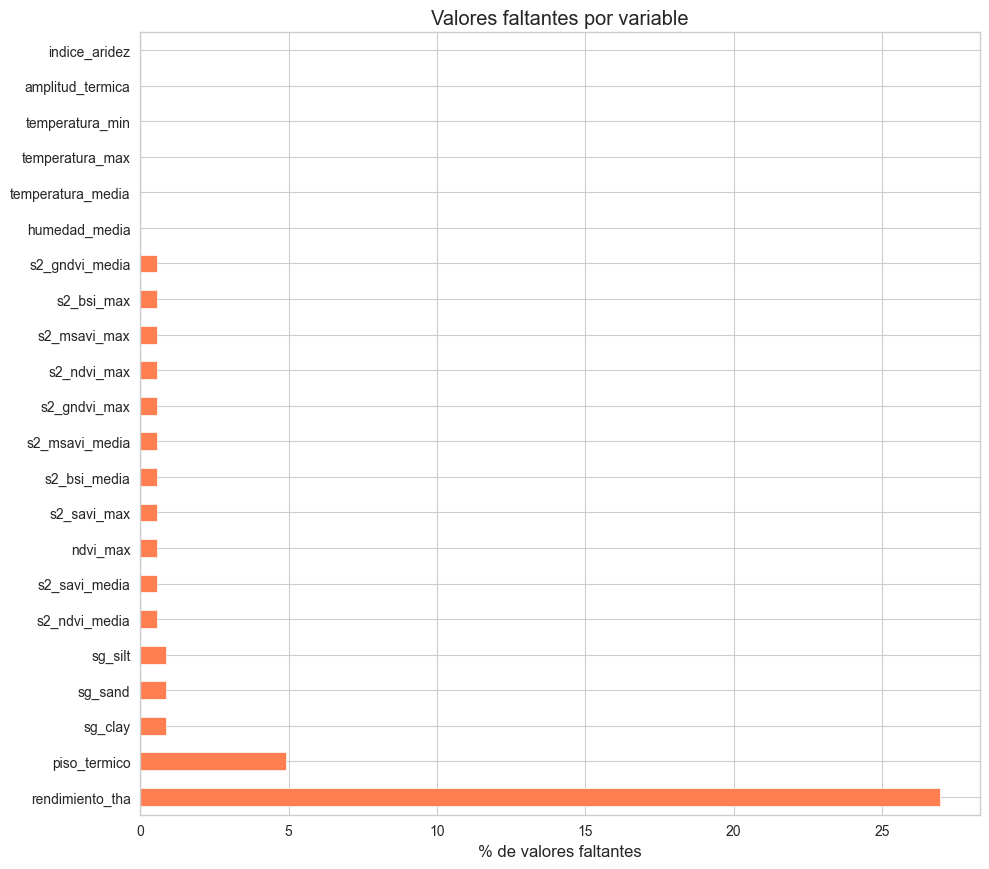

In [62]:
# Visualización de valores faltantes
missing_nonzero = missing_df[missing_df['n_missing'] > 0]
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_nonzero)*0.4)))
    missing_nonzero['pct_missing'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Valores faltantes por variable')
    plt.tight_layout()
else:
    print("No se encontraron valores faltantes significativos.")

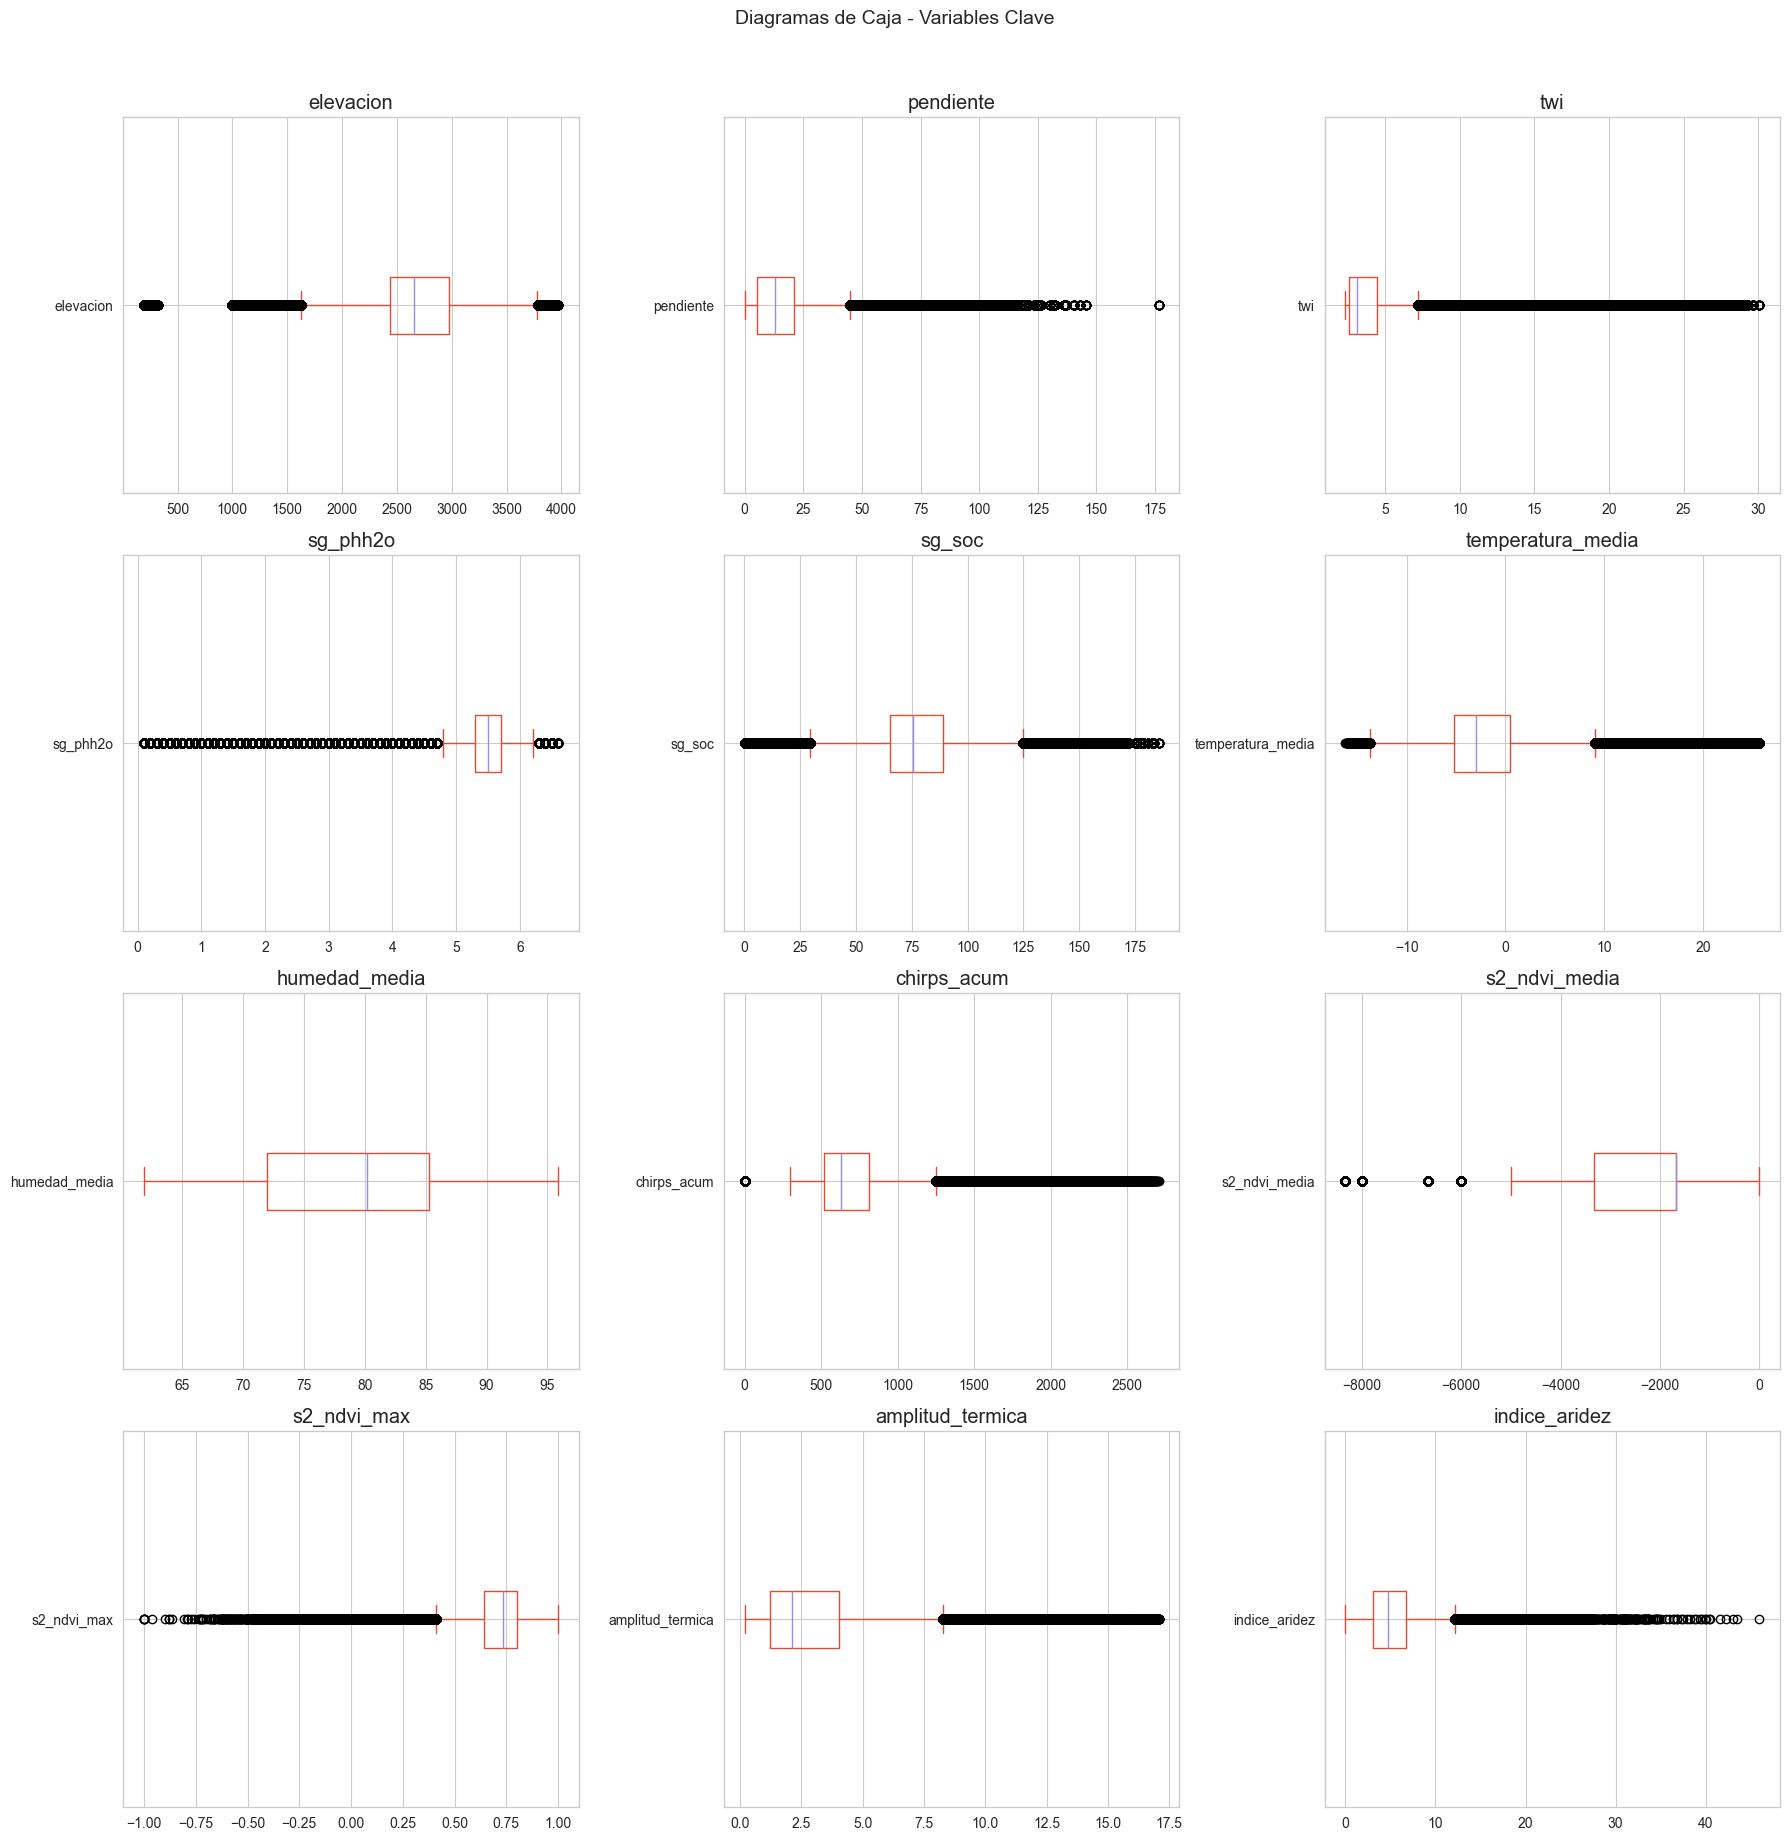

In [63]:
# Detección de outliers con diagramas de caja para variables numéricas clave
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
# Excluir ids y coordenadas
exclude = ['pixel_id', 'cultivo_id']
plot_cols = [c for c in numeric_cols if c not in exclude]

# Seleccionar un subconjunto de variables clave para visualización
key_vars = ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc',
            'temperatura_media', 'humedad_media', 'chirps_acum',
            's2_ndvi_media', 's2_ndvi_max', 'amplitud_termica', 'indice_aridez']
key_vars = [v for v in key_vars if v in df_raw.columns]

fig, axes = plt.subplots(len(key_vars)//3, 3, figsize=(18, len(key_vars)*1.5))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().plot(kind='box', ax=axes[i], vert=False)
        axes[i].set_title(col)
plt.suptitle('Diagramas de Caja - Variables Clave', y=1.02, fontsize=14)
plt.tight_layout()

### 2.6 Análisis de Distribuciones

In [64]:
# Distribución del target - Balance de clases
target_col = 'cultivo_id'
print("Distribución de clases (cultivo_id):")
class_dist = df_raw[target_col].value_counts().sort_index()
class_pct = (df_raw[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

for cls in class_dist.index:
    name = inv_catalogo.get(cls, f"Clase_{cls}")
    print(f"  {cls:2d} ({name:<16}): {class_dist[cls]:>10,} ({class_pct[cls]:>6.2f}%)")

print(f"\nRatio de desbalance: {class_dist.max() / max(class_dist.min(), 1):.0f}:1")
print(f"\nFuentes del target (L1/L2/L3):")
print(df_raw.groupby('fuente')['confianza'].agg(['count', 'mean']).round(3))


Distribución de clases (cultivo_id):
   0 (Papa            ):  2,604,695 ( 48.09%)
   1 (Cana_Panelera   ):     77,958 (  1.44%)
   2 (Cafe            ):    156,331 (  2.89%)
   3 (Maiz            ):    135,818 (  2.51%)
   4 (Platano         ):      9,497 (  0.18%)
   5 (Mango           ):     12,537 (  0.23%)
   6 (Frijol          ):    109,067 (  2.01%)
   7 (Cacao           ):     32,430 (  0.60%)
   8 (Arveja          ):      2,760 (  0.05%)
   9 (Palma           ):     85,455 (  1.58%)
  10 (Banano          ):     15,839 (  0.29%)
  12 (Otros_cultivos  ):    713,954 ( 13.18%)
  13 (No_apto         ):  1,459,620 ( 26.95%)

Ratio de desbalance: 944:1

Fuentes del target (L1/L2/L3):
                 count   mean
fuente                       
eva_municipal  3390312 0.7000
monitoreo       566029 1.0000
noapto_proxy   1459620 0.4000


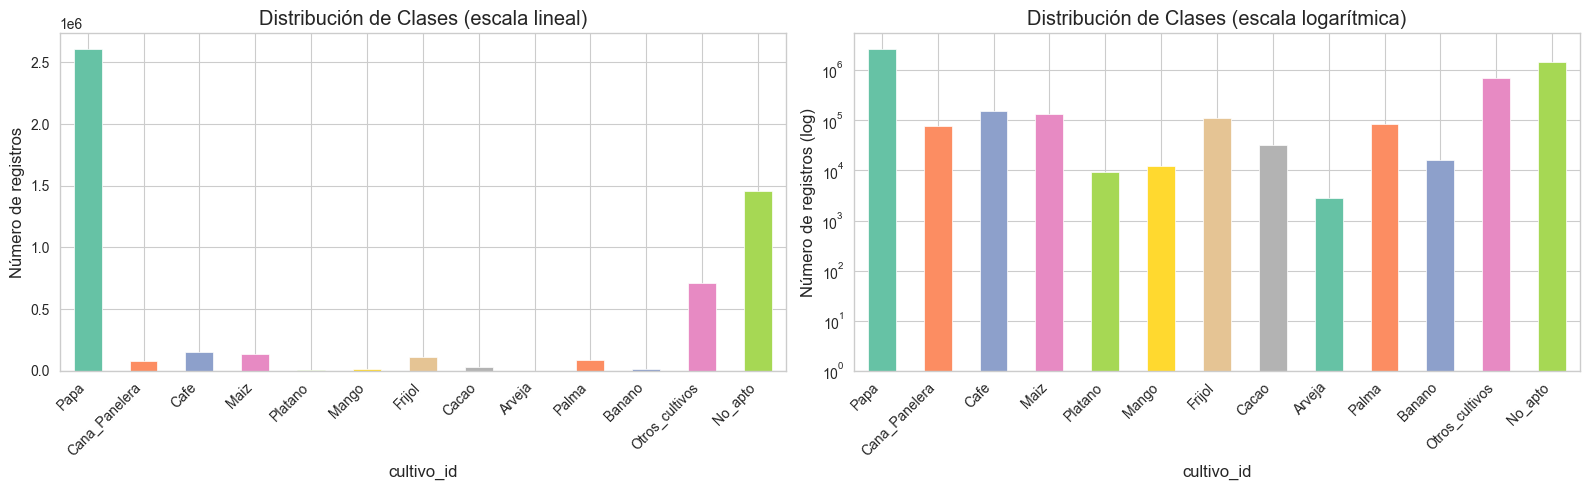

In [65]:
# Visualización del balance de clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

labels = [inv_catalogo.get(c, f'C{c}') for c in class_dist.index]

class_dist.plot(kind='bar', ax=ax1, color=sns.color_palette("Set2", len(class_dist)))
ax1.set_title('Distribución de Clases (escala lineal)')
ax1.set_xlabel('cultivo_id')
ax1.set_ylabel('Número de registros')
ax1.set_xticklabels(labels, rotation=45, ha='right')

class_dist.plot(kind='bar', ax=ax2, color=sns.color_palette("Set2", len(class_dist)), log=True)
ax2.set_title('Distribución de Clases (escala logarítmica)')
ax2.set_xlabel('cultivo_id')
ax2.set_ylabel('Número de registros (log)')
ax2.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()


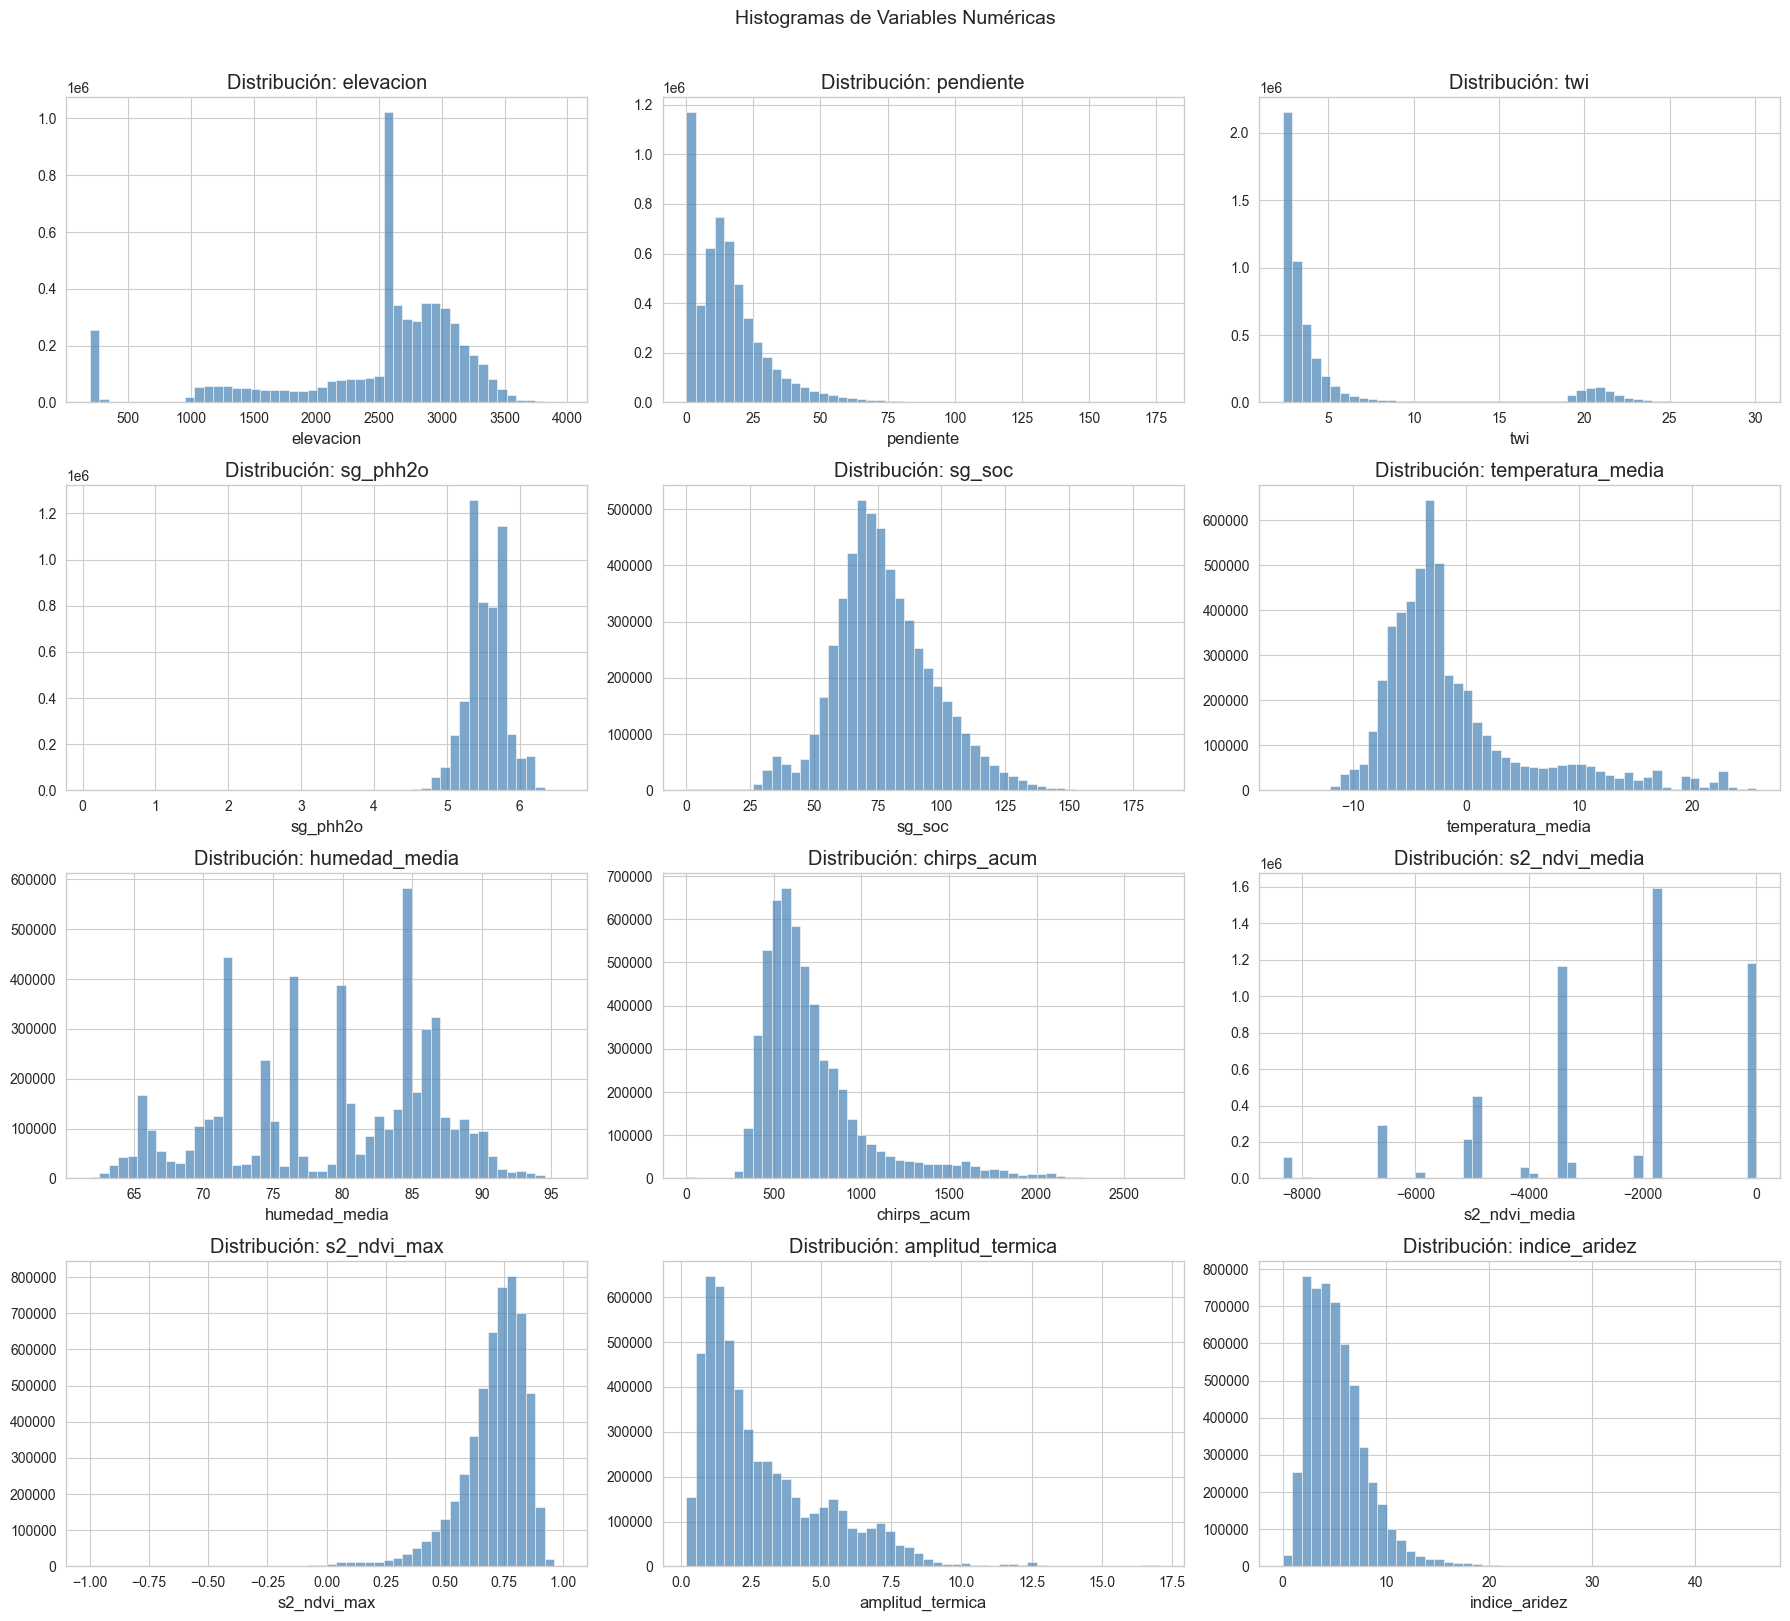

In [66]:
# Histogramas de variables numéricas clave
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(f'Distribución: {col}')
        axes[i].set_xlabel(col)
plt.suptitle('Histogramas de Variables Numéricas', y=1.01, fontsize=14)
plt.tight_layout()

### 2.7 Detección de Patrones - Correlaciones

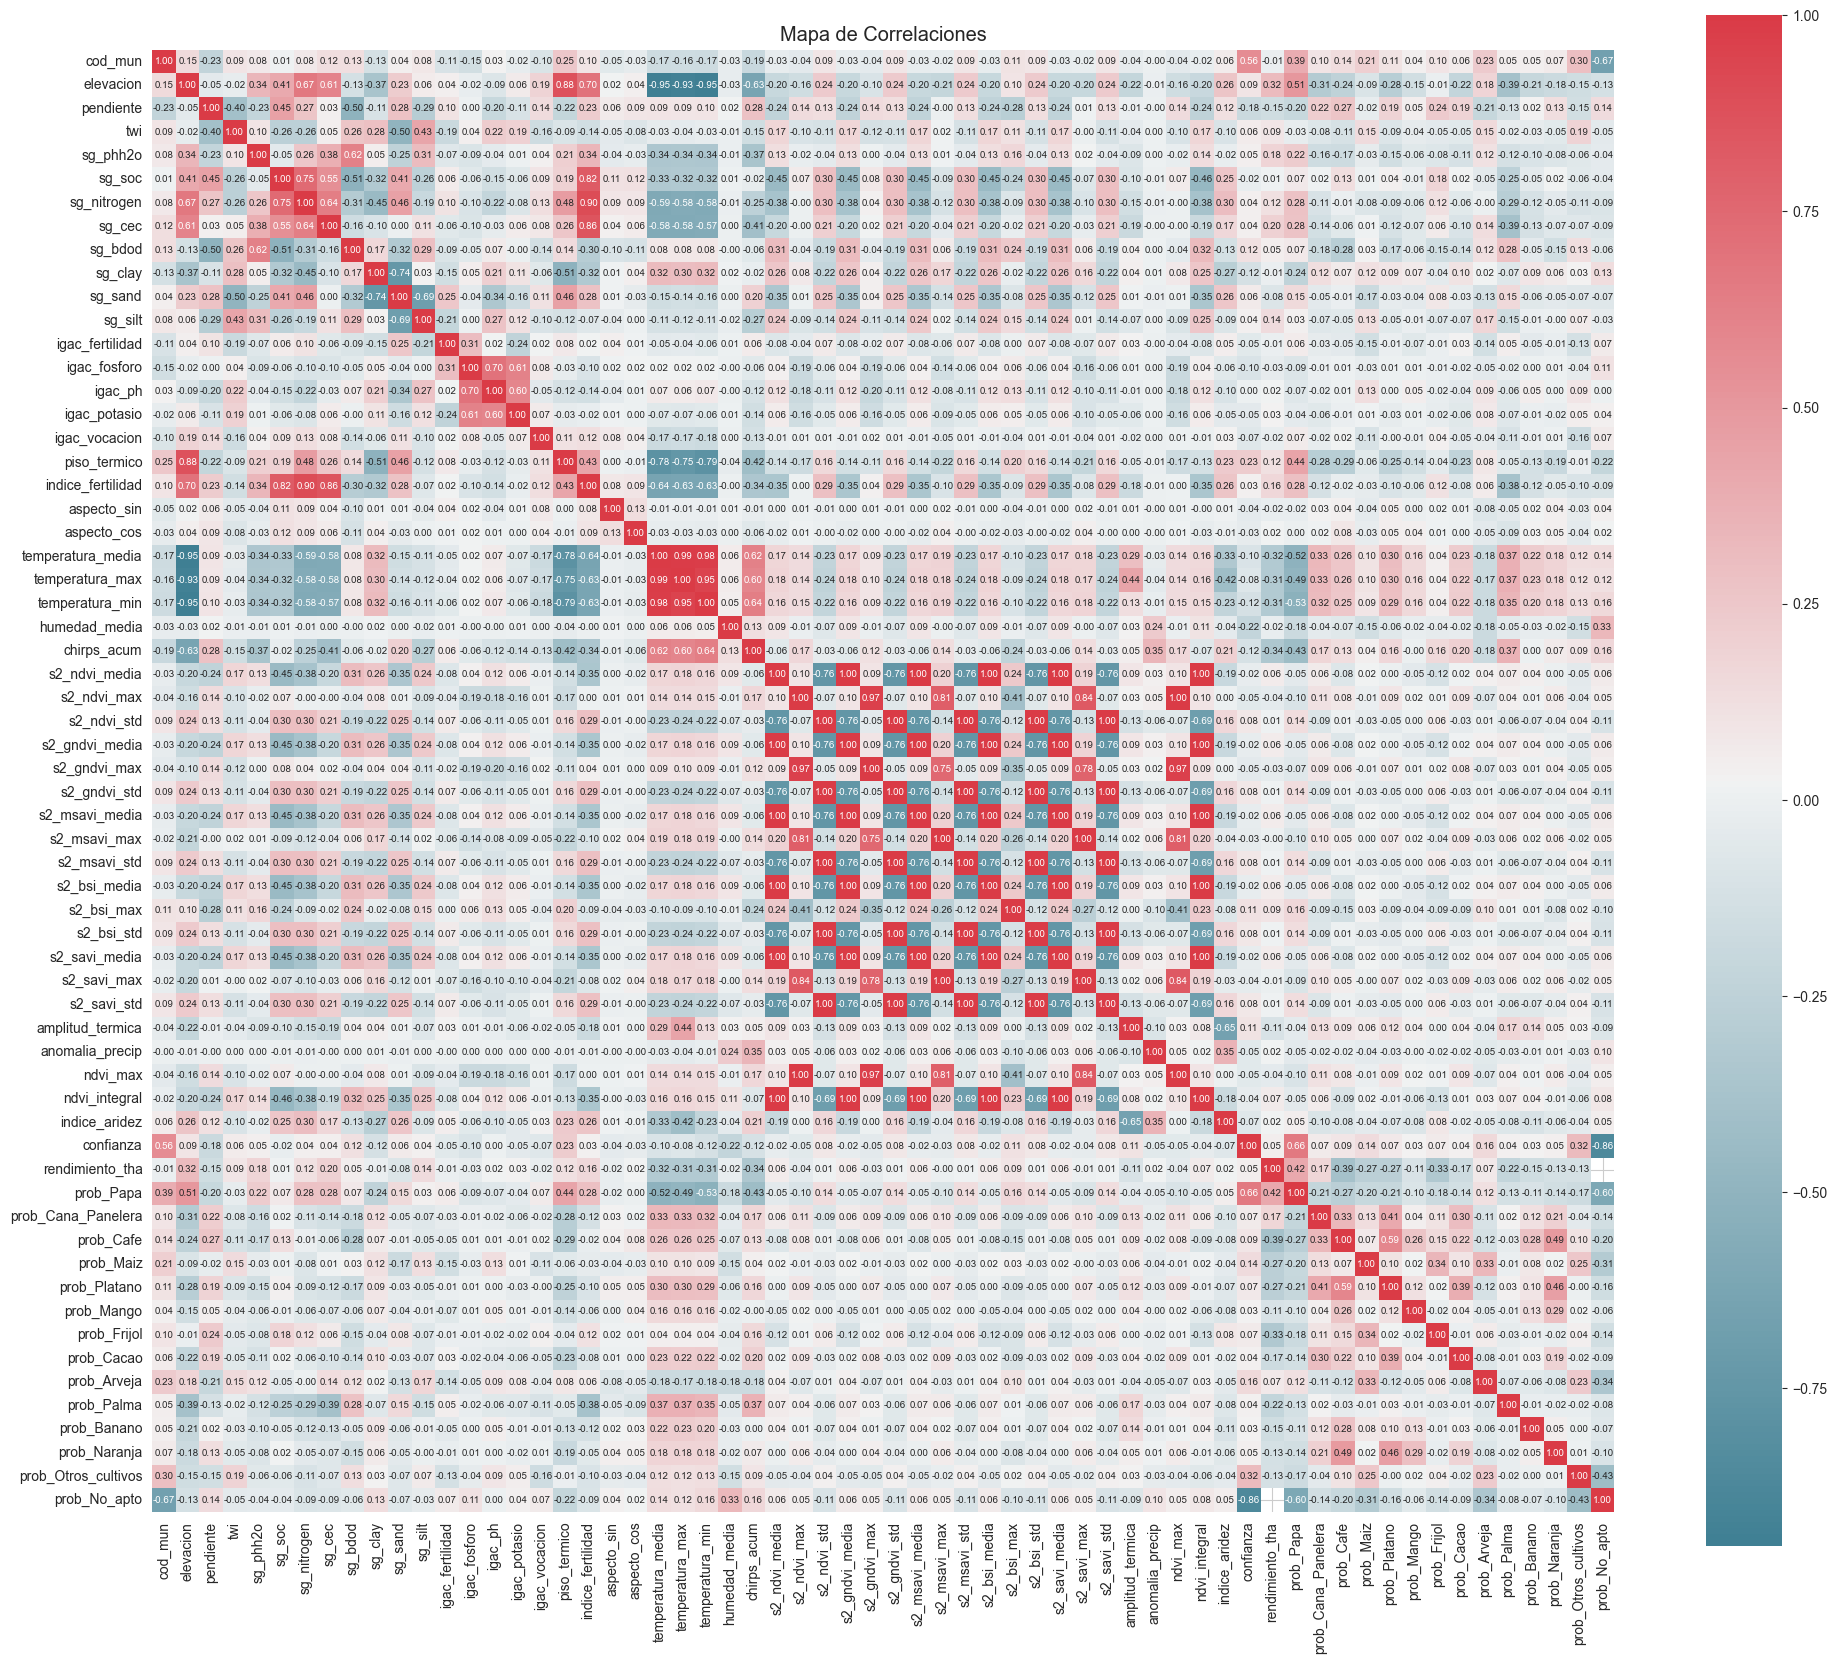

In [67]:
# Mapa de correlación de variables numéricas (sin IDs ni coordenadas)
corr_cols = [c for c in numeric_cols if c not in ['pixel_id', 'x', 'y', 'cultivo_id']]
corr_cols = [c for c in corr_cols if df_raw[c].notna().sum() > 0]  # solo cols con datos
plot_correlation_map(df_raw[corr_cols], figsize=(20, 18))

Top 15 variables más correlacionadas con cultivo_id:
  prob_Papa: -0.8180
  prob_No_apto: +0.7466
  confianza: -0.6771
  cod_mun: -0.4959
  temperatura_min: +0.3536
  elevacion: -0.3460
  temperatura_media: +0.3324
  rendimiento_tha: -0.3324
  chirps_acum: +0.3275
  piso_termico: -0.3162
  temperatura_max: +0.3090
  prob_Arveja: -0.2812
  humedad_media: +0.2380
  indice_fertilidad: -0.2321
  sg_nitrogen: -0.2292


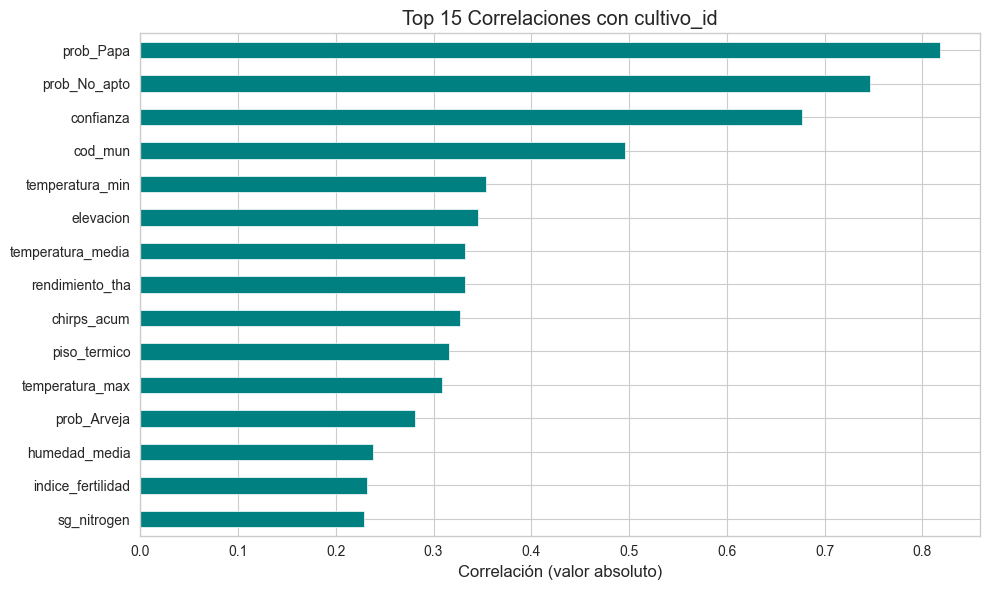

In [68]:
# Correlaciones más fuertes con el target
if target_col in df_raw.columns:
    correlations = df_raw[corr_cols + [target_col]].corr()[target_col].drop(target_col)
    top_corr = correlations.abs().sort_values(ascending=False).head(15)
    print("Top 15 variables más correlacionadas con cultivo_id:")
    for var in top_corr.index:
        print(f"  {var}: {correlations[var]:+.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    top_corr.sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 Correlaciones con cultivo_id')
    ax.set_xlabel('Correlación (valor absoluto)')
    plt.tight_layout()

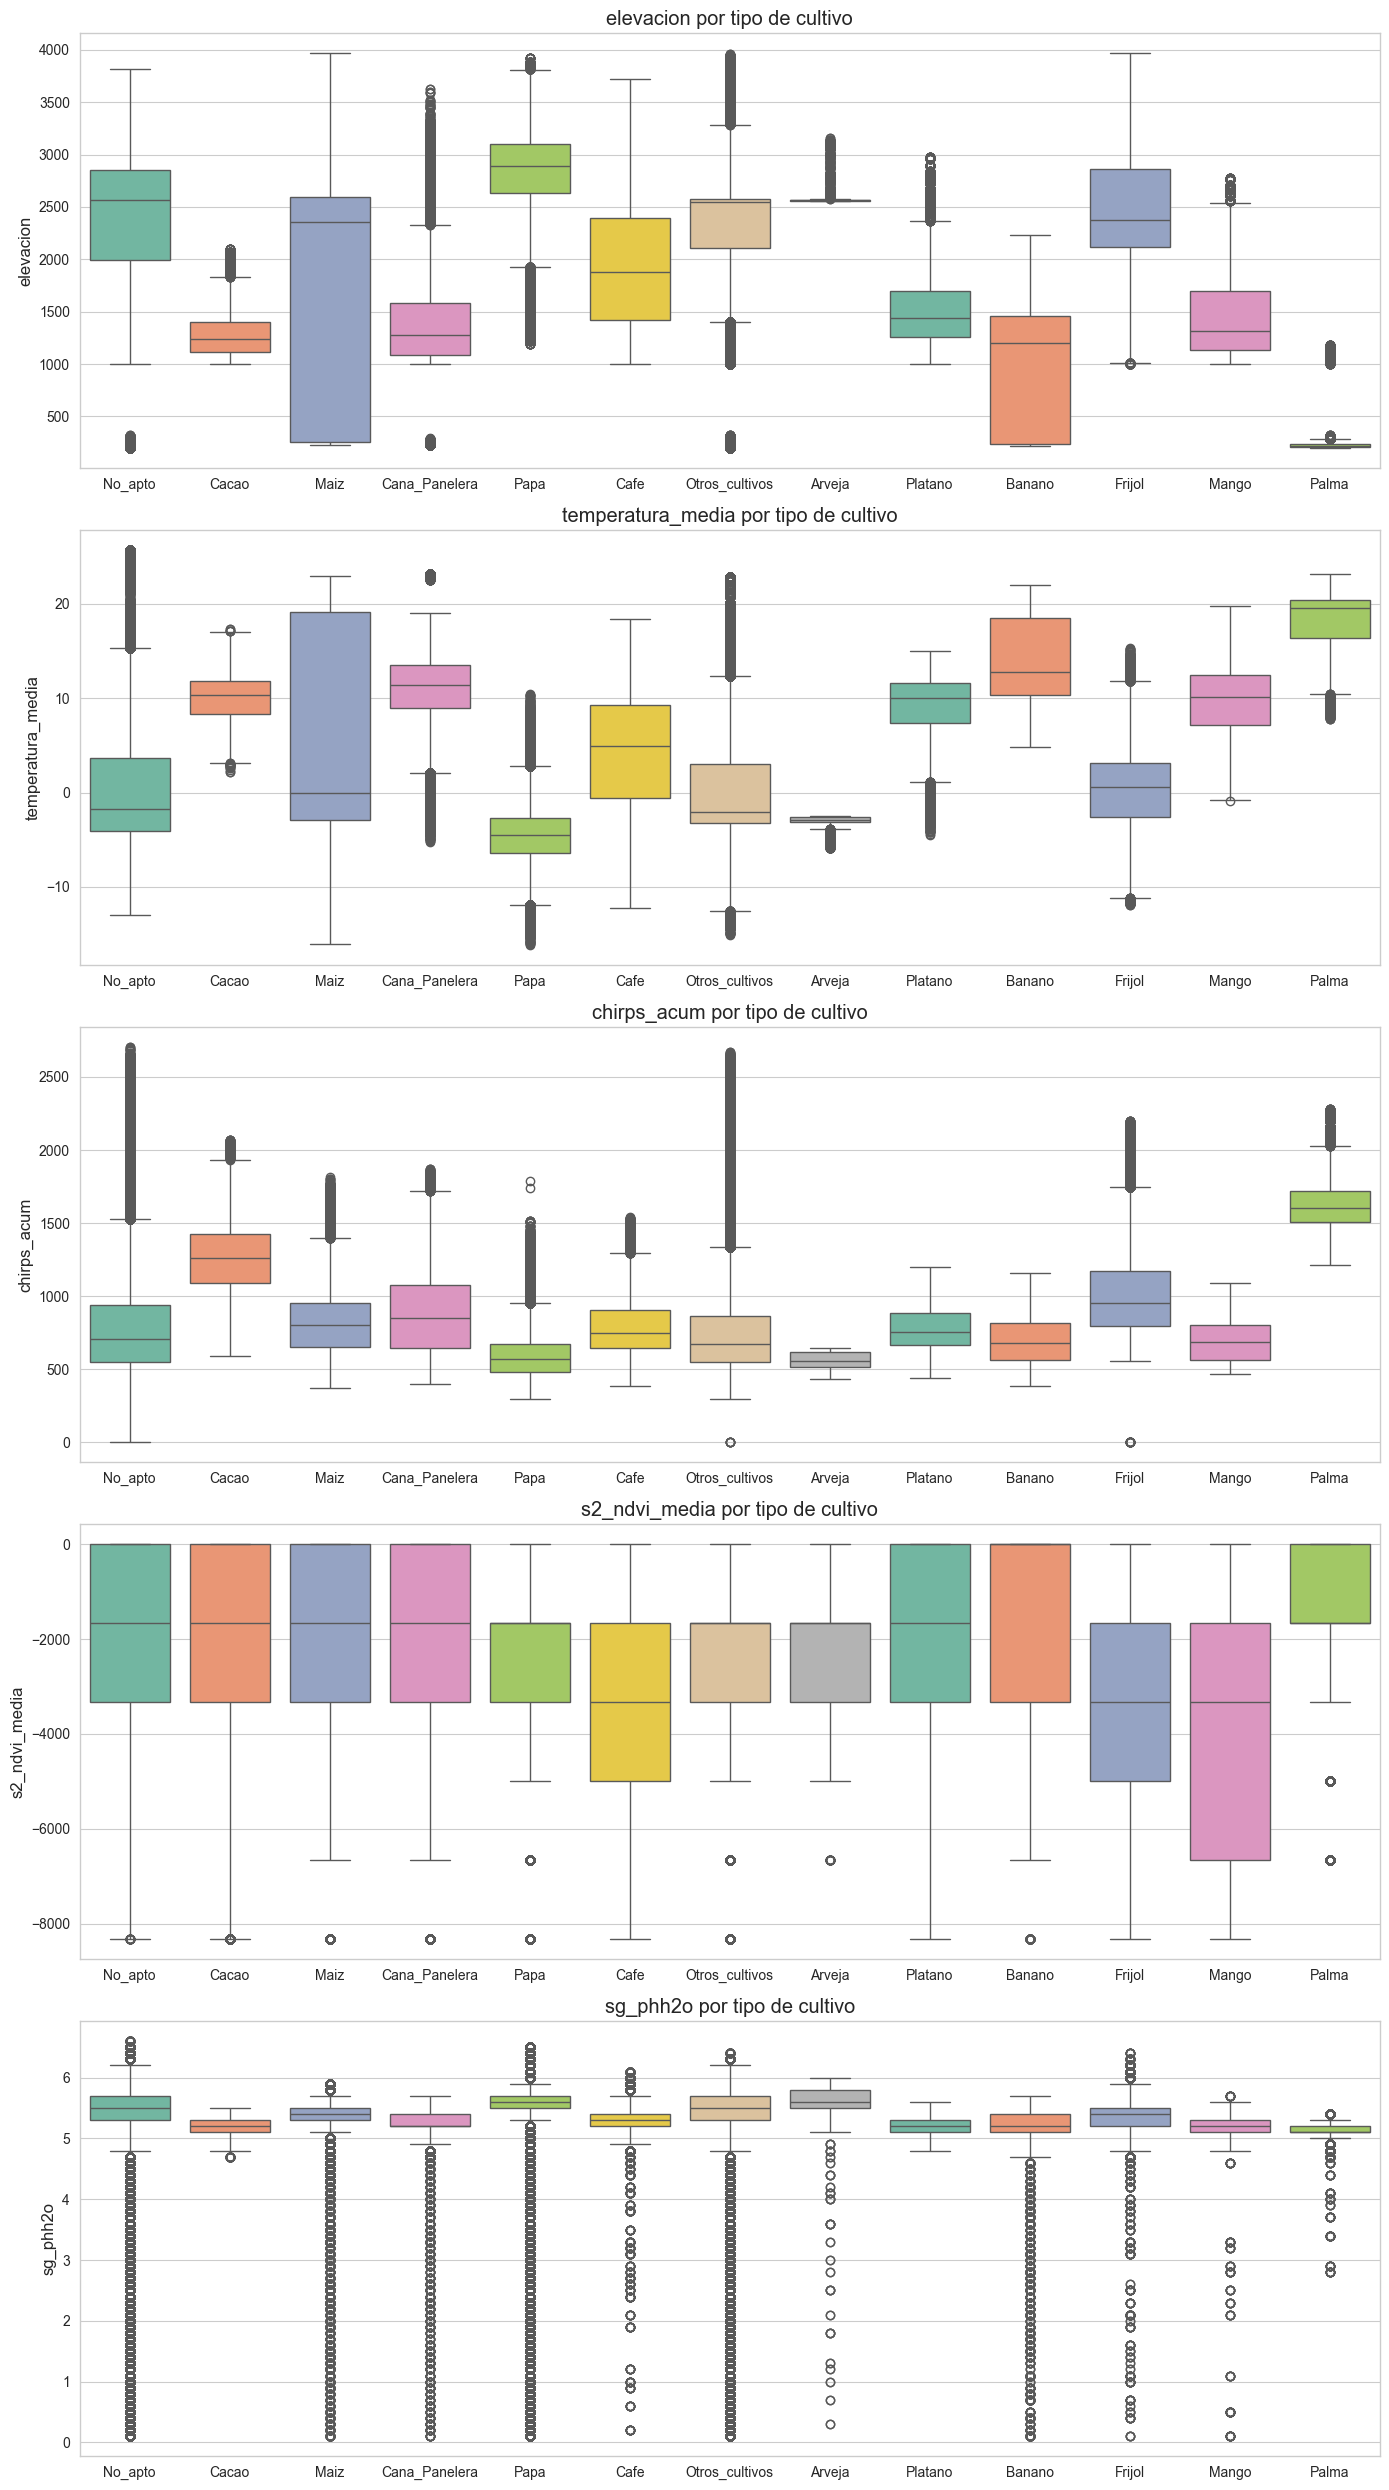

In [69]:
# Distribución de variables clave por cultivo (boxplots)
df_plot = df_raw.copy()
df_plot['cultivo_nombre'] = df_plot['cultivo_id'].map(inv_catalogo)

vars_por_cultivo = ['elevacion', 'temperatura_media', 'chirps_acum', 's2_ndvi_media', 'sg_phh2o']
vars_por_cultivo = [v for v in vars_por_cultivo if v in df_plot.columns]

fig, axes = plt.subplots(len(vars_por_cultivo), 1, figsize=(14, 5*len(vars_por_cultivo)))
for i, var in enumerate(vars_por_cultivo):
    sns.boxplot(data=df_plot, x='cultivo_nombre', y=var, ax=axes[i],
                palette='Set2', hue='cultivo_nombre', legend=False)
    axes[i].set_title(f'{var} por tipo de cultivo')
    axes[i].set_xlabel('')
plt.tight_layout()

### 2.8 Resumen de Comprensión de Datos

A partir del análisis exploratorio:

* **Dimensiones**: varios millones de registros para 14 clases de cultivo distribuidas en Cundinamarca.
* **Etiquetado jerárquico**: la columna `fuente` distingue L1 (monitoreo UPRA, alta confianza), L2 (EVA municipal, confianza moderada) y L3 (No_apto proxy, confianza baja). El modelo usará `sample_weight = confianza` para que los L1 dominen el ajuste.
* **Desbalance de clases**: Papa (por monitoreo UPRA) y No_apto (por proxy SIPRA/NDVI) concentran la mayoría de registros. Las clases minoritarias dependen de L2 EVA municipal.
* **Valores faltantes**: algunas variables satélite tienen NaNs por cobertura de nubes; se imputan por mediana.
* **Correlaciones**: Temperatura y elevación siguen muy correlacionadas (r≈-0.95). NDVI y GNDVI son casi redundantes.
* **Leakage esperado con NDVI**: `ndvi_max` se mantiene como feature aunque alimente la regla L3. El modelo reproducirá la lógica `NDVI bajo → No_apto`, que es precisamente la semántica correcta ("pixel no vegetado").
* **Particionamiento**: se usará split **por municipio** (`GroupShuffleSplit`) en lugar de estratificado aleatorio, para evitar fuga espacial entre pixeles vecinos.


---

# 3. Preparación de los Datos

### 3.1 Estrategia
- Excluir identificadores irrelevantes (`pixel_id`, `x`, `y`, `cod_mun`) y target secundarios (`cultivo`, `fuente`, `rendimiento_tha`, `confianza`).
- `confianza` se reserva como `sample_weight` en `fit()` (no entra como feature).
- `cod_mun` se reserva como `groups` para `GroupShuffleSplit` y `GroupKFold`.
- Codificación cíclica para features temporales (`semestre`).
- Separar variables por tipo (numéricas continuas, ordinales, nominales).
- Construir un preprocesador reutilizable con `Pipeline` y `ColumnTransformer`.
- **Sin SMOTE**: incompatible con `sample_weight` (los sintéticos no tienen una confianza real). Se usará `class_weight='balanced'` en LR/RF y pesos directos en XGBoost.
- Split train/valid/test **por municipio** (70/15/15 aprox), para evitar que pixeles vecinos caigan en folds distintos.


In [70]:
# --- Definición de columnas ---

# Columnas a excluir (metadata, ids, target secundarios)
EXCLUDE_COLS = [
    'pixel_id', 'x', 'y',                 # Metadata espacial
    'cod_mun',                            # Identificador de municipio (se usa como groups)
    'cultivo',                            # Target como string (usamos cultivo_id)
    'confianza',                          # Se usa como sample_weight, NO como feature
    'fuente',                             # Etiqueta de nivel (L1/L2/L3), no feature
    'rendimiento_tha',                    # Target secundario
    'temperatura_max', 'temperatura_min', # Redundantes con temperatura_media (r>0.98)
    's2_savi_media', 's2_savi_max', 's2_savi_std',  # Redundantes con MSAVI
    'ndvi_max',                           # Duplicado exacto de s2_ndvi_max
]

# prob_<cultivo> son target SOFT (P(clase|pixel)) y cultivo_id = argmax(prob_*).
# Usarlas como features es target leakage directo. Se excluyen aqui y se consumen
# SOLO en la expansion soft-label (celda 3.3) o como target soft en la perdida.
EXCLUDE_COLS += [c for c in df_raw.columns if c.startswith('prob_')]

# Features temporales para codificación cíclica
CYCLIC_COL = 'semestre'

# Target y columnas auxiliares
TARGET_COL = 'cultivo_id'
WEIGHT_COL = 'confianza'   # sample_weight
GROUP_COL = 'cod_mun'      # para GroupKFold / GroupShuffleSplit

print("Columnas excluidas definidas.")
print(f"Target:  {TARGET_COL}")
print(f"Peso:    {WEIGHT_COL}  (sample_weight)")
print(f"Grupos:  {GROUP_COL}   (GroupKFold)")


Columnas excluidas definidas.
Target:  cultivo_id
Peso:    confianza  (sample_weight)
Grupos:  cod_mun   (GroupKFold)


In [71]:
# --- Codificacion temporal del semestre ---
# Con solo 2 valores (A, B), la codificacion sin/cos es redundante:
#   sin(0) = 0, sin(pi) = 0 -> columna constante.
# Conservamos solo `semestre_cos` (={1: A, -1: B}) como feature binaria
# con semantica circular. Para `year_norm` usamos el rango fijo del
# proyecto (YEAR_START=2020, YEAR_END=2025) en vez de df.min()/df.max(),
# evitando leakage del test set al encoding.

YEAR_MIN = 2020   # ventana temporal del proyecto (config.YEAR_START)
YEAR_MAX = 2025   # config.YEAR_END


def encode_semestre_cyclic(df):
    """Convierte 'YYYYA'/'YYYYB' en (semestre_cos, year_norm).

    - semestre_cos: 1.0 si A, -1.0 si B (equivalente a cos(pi*k) con k in {0,1}).
    - year_norm: (year - YEAR_MIN) / (YEAR_MAX - YEAR_MIN), tendencia temporal.
    """
    df = df.copy()
    year = df['semestre'].str[:4].astype(int)
    sem = df['semestre'].str[4].map({'A': 0, 'B': 1})

    df['semestre_cos'] = np.cos(np.pi * sem).astype(np.float32)  # {1, -1}
    df['year_norm'] = ((year - YEAR_MIN) / (YEAR_MAX - YEAR_MIN)).astype(np.float32)

    df.drop(columns=['semestre'], inplace=True)
    return df


# Aplicar codificacion
df = df_raw.copy()
df = encode_semestre_cyclic(df)
print(f"Columnas despues de codificacion: {df.shape[1]}")
print(f"Nuevas columnas: semestre_cos (in {{-1, 1}}), year_norm (in [0, 1])")

df[['semestre_cos', 'year_norm']].describe()


Columnas despues de codificacion: 70
Nuevas columnas: semestre_cos (in {-1, 1}), year_norm (in [0, 1])


,semestre_cos,year_norm
count,5415961.0000,5415961.0000
mean,0.0004,0.4879
std,1.0000,0.3361
min,-1.0000,0.0000
25%,-1.0000,0.2000
50%,1.0000,0.4000
75%,1.0000,0.8000
max,1.0000,1.0000


In [72]:
# --- Separar X, y, sample_weight y groups ---

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != TARGET_COL]
X = df[feature_cols]
y = df[TARGET_COL]
w = df[WEIGHT_COL].astype(float)     # sample_weight = confianza
groups = df[GROUP_COL].astype(int)   # cod_mun

print(f"Features: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")
print(f"Municipios únicos: {groups.nunique()}")
print(f"\nDistribución de pesos (confianza):")
print(w.describe().round(3))


Features: 41
Registros: 5,415,961
Municipios únicos: 113

Distribución de pesos (confianza):
count   5415961.0000
mean          0.6510
std           0.1770
min           0.4000
25%           0.4000
50%           0.7000
75%           0.7000
max           1.0000
Name: confianza, dtype: float64


In [73]:
# --- Clasificar features por tipo ---

# Variables ordinales IGAC (ya son numericas con orden natural)
ordinal_cols = ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
ordinal_cols = [c for c in ordinal_cols if c in feature_cols]

# Variable nominal
nominal_cols = ['igac_vocacion']
nominal_cols = [c for c in nominal_cols if c in feature_cols]

# Features temporales (ya codificadas): semestre_cos binaria + tendencia year_norm
cyclic_cols = ['semestre_cos', 'year_norm']
cyclic_cols = [c for c in cyclic_cols if c in feature_cols]

# Numericas continuas (resto)
numeric_continuous = [c for c in feature_cols
                      if c not in ordinal_cols + nominal_cols + cyclic_cols]

print(f"Variables ordinales ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Variables nominales ({len(nominal_cols)}): {nominal_cols}")
print(f"Variables temporales ({len(cyclic_cols)}): {cyclic_cols}")
print(f"Variables continuas ({len(numeric_continuous)}): {numeric_continuous}")


Variables ordinales (5): ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
Variables nominales (1): ['igac_vocacion']
Variables temporales (2): ['semestre_cos', 'year_norm']
Variables continuas (33): ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_integral', 'indice_aridez']


In [74]:
# --- Partición espacial por municipio: 70% train, 15% validación, 15% prueba ---
# Usamos GroupShuffleSplit con la columna cod_mun para garantizar que los pixeles
# de un municipio dado solo aparezcan en UN fold. Esto evita la fuga espacial
# (pixeles vecinos con features muy correlacionadas en train y test).

from sklearn.model_selection import GroupShuffleSplit

# Muestreo estratificado por capacidad de cómputo (manteniendo pesos y grupos)
MAX_SAMPLES = 1_500_000
if len(X) > MAX_SAMPLES:
    print(f"Dataset muy grande ({len(X):,}). Tomando muestra aleatoria de {MAX_SAMPLES:,}...")
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X), MAX_SAMPLES, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)
    w = w.iloc[idx].reset_index(drop=True)
    groups = groups.iloc[idx].reset_index(drop=True)
    print(f"Muestra resultante: {X.shape[0]:,} registros, {groups.nunique()} municipios")

# Split 1: separar test (15% de municipios)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
idx_trv, idx_test = next(gss1.split(X, y, groups=groups))

X_train_valid = X.iloc[idx_trv].reset_index(drop=True)
y_train_valid = y.iloc[idx_trv].reset_index(drop=True)
w_train_valid = w.iloc[idx_trv].reset_index(drop=True)
g_train_valid = groups.iloc[idx_trv].reset_index(drop=True)

X_test = X.iloc[idx_test].reset_index(drop=True)
y_test = y.iloc[idx_test].reset_index(drop=True)
w_test = w.iloc[idx_test].reset_index(drop=True)

# Split 2: separar validación (15% de municipios del subset restante)
valid_size = 0.15 / 0.85
gss2 = GroupShuffleSplit(n_splits=1, test_size=valid_size, random_state=42)
idx_tr, idx_va = next(gss2.split(X_train_valid, y_train_valid, groups=g_train_valid))

X_train = X_train_valid.iloc[idx_tr].reset_index(drop=True)
y_train = y_train_valid.iloc[idx_tr].reset_index(drop=True)
w_train = w_train_valid.iloc[idx_tr].reset_index(drop=True)
g_train = g_train_valid.iloc[idx_tr].reset_index(drop=True)

X_valid = X_train_valid.iloc[idx_va].reset_index(drop=True)
y_valid = y_train_valid.iloc[idx_va].reset_index(drop=True)
w_valid = w_train_valid.iloc[idx_va].reset_index(drop=True)

print(f"\nParticiones por municipio:")
print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)  |  "
      f"municipios: {g_train.nunique()}")
print(f"  Valid: {len(X_valid):,} ({len(X_valid)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verificación: no debe haber intersección de municipios entre train/test
assert len(set(g_train) & set(groups.iloc[idx_test])) == 0, \
    "Leakage detectado: municipios en train y test"
print("\n  OK: sin intersección de municipios entre train/valid/test")

# ── Remapeo de etiquetas a espacio compacto [0..K-1] ──
# XGBoost (multi:softprob) requiere labels contiguos empezando en 0.
# Estrategia: fit del LabelEncoder SOLO sobre y_train (el modelo solo puede
# aprender lo que ve). Filtrar filas de valid/test cuya clase no este en
# train -- el modelo no podria predecirlas correctamente y su inclusion
# provoca el error "Invalid classes inferred" en XGBoost.
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le_y = LabelEncoder()
le_y.fit(y_train)

# Filtrar valid/test a clases conocidas en train (mantener X, w, g alineados)
mask_v = y_valid.isin(le_y.classes_)
mask_t = y_test.isin(le_y.classes_)
n_drop_v = int((~mask_v).sum())
n_drop_t = int((~mask_t).sum())
if n_drop_v or n_drop_t:
    print(f"  Filas descartadas por clase ausente en train: "
          f"valid={n_drop_v}, test={n_drop_t}")
    X_valid = X_valid[mask_v].reset_index(drop=True)
    y_valid = y_valid[mask_v].reset_index(drop=True)
    w_valid = w_valid[mask_v].reset_index(drop=True)
    X_test = X_test[mask_t].reset_index(drop=True)
    y_test = y_test[mask_t].reset_index(drop=True)
    w_test = w_test[mask_t].reset_index(drop=True)

# Remap al espacio [0..K-1]
y_train = pd.Series(le_y.transform(y_train), index=y_train.index)
y_valid = pd.Series(le_y.transform(y_valid), index=y_valid.index)
y_test = pd.Series(le_y.transform(y_test), index=y_test.index)

# Nombres para el reporte: le_y.classes_[k] = id_original -> inv_catalogo -> nombre
target_names_remap = [inv_catalogo.get(int(c), f'Clase_{c}') for c in le_y.classes_]

print(f"\nClases en train (modelo): {len(le_y.classes_)} de {len(catalogo)} en catalogo")
ausentes = sorted(set(catalogo.values()) - set(int(c) for c in le_y.classes_))
if ausentes:
    print(f"  Ausentes en train: "
          f"{[inv_catalogo[c] for c in ausentes]}  (ids {ausentes})")


Dataset muy grande (5,415,961). Tomando muestra aleatoria de 1,500,000...
Muestra resultante: 1,500,000 registros, 113 municipios

Particiones por municipio:
  Train: 970,350 (64.7%)  |  municipios: 79
  Valid: 135,638 (9.0%)
  Test:  394,012 (26.3%)

  OK: sin intersección de municipios entre train/valid/test
  Filas descartadas por clase ausente en train: valid=0, test=23480

Clases en train (modelo): 12 de 14 en catalogo
  Ausentes en train: ['Palma', 'Naranja']  (ids [9, 11])


In [75]:
# --- Preprocesador con ColumnTransformer ---

# Pipeline para variables continuas: imputación + escalamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables ordinales: imputación (ya son numéricas)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Pipeline para variables nominales: imputación + one-hot
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_continuous),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('cyclic', 'passthrough', cyclic_cols)
], remainder='drop')

print("Preprocesador construido:")
print(preprocessor)

Preprocesador construido:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['elevacion', 'pendiente', 'twi', 'sg_phh2o',
                                  'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod',
                                  'sg_clay', 'sg_sand', 'sg_silt',
                                  'indice_fertilidad', 'aspecto_sin',
                                  'aspecto_cos', 'temperatura_media',
                                  'humedad_media', 'chirps_acum',
                                  's2_ndvi...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['igac_ph', 'igac_fosforo', 'igac_potasio

In [76]:
# --- Aplicar preprocesamiento ---
# NO se aplica SMOTE: es incompatible con sample_weight.
# Los pesos por fila (confianza) ya se encargan del desbalance efectivo.

X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)
X_test_prep = preprocessor.transform(X_test)

print(f"Datos preprocesados:")
print(f"  X_train: {X_train_prep.shape}")
print(f"  X_valid: {X_valid_prep.shape}")
print(f"  X_test:  {X_test_prep.shape}")

# Nombres de features después del preprocesamiento
feature_names = list(numeric_continuous) + list(ordinal_cols)
if nominal_cols:
    ohe = preprocessor.named_transformers_['nom'].named_steps['encoder']
    nominal_encoded = list(ohe.get_feature_names_out(nominal_cols))
    feature_names += nominal_encoded
feature_names += cyclic_cols
print(f"\nTotal features después de preprocesamiento: {len(feature_names)}")


Datos preprocesados:
  X_train: (970350, 48)
  X_valid: (135638, 48)
  X_test:  (370532, 48)

Total features después de preprocesamiento: 48


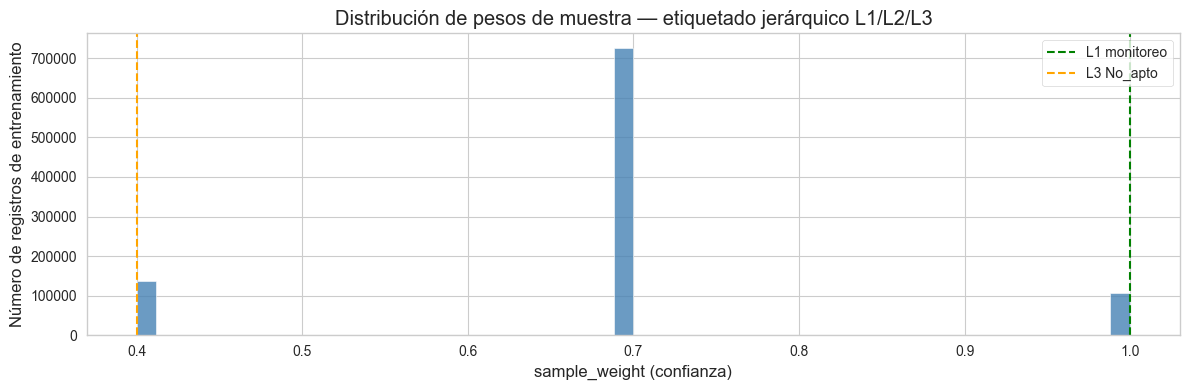

In [77]:
# --- Distribución de pesos (confianza) en entrenamiento ---
# El sample_weight es la herencia del etiquetado jerárquico:
#   conf=1.0 -> monitoreo UPRA (L1, ground truth)
#   conf=0.3-0.7 -> EVA municipal (L2, etiqueta inferida de aptitud)
#   conf=0.4 -> No_apto proxy (L3)

fig, ax = plt.subplots(figsize=(12, 4))
w_train.hist(bins=50, ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('sample_weight (confianza)')
ax.set_ylabel('Número de registros de entrenamiento')
ax.set_title('Distribución de pesos de muestra — etiquetado jerárquico L1/L2/L3')
ax.axvline(1.0, color='green', ls='--', label='L1 monitoreo')
ax.axvline(0.4, color='orange', ls='--', label='L3 No_apto')
ax.legend()
plt.tight_layout()


In [78]:
# --- Peso efectivo = inverse-frequency x confianza ---
# El `sample_weight = confianza` refleja CALIDAD de la etiqueta (L1/L2/L3),
# no el balance de clases. Con 14 clases muy desbalanceadas (Papa y No_apto
# dominan), XGBoost necesita un factor adicional que contrarreste la frecuencia.
#
# Combinamos ambas senales:
#   eff_w = class_weight_balanced(y) * confianza
# Asi:
#   - una clase minoritaria con etiqueta L1 (papa rara alta altitud) pesa mucho,
#   - una clase mayoritaria con etiqueta L2 de baja confianza pesa poco,
#   - se reduce el colapso hacia Papa/No_apto del XGBoost.

from sklearn.utils.class_weight import compute_sample_weight

cw_train = compute_sample_weight('balanced', y_train)
cw_valid = compute_sample_weight('balanced', y_valid)
cw_test  = compute_sample_weight('balanced', y_test)

eff_w_train = cw_train * w_train.values
eff_w_valid = cw_valid * w_valid.values
eff_w_test  = cw_test  * w_test.values

print("Pesos efectivos (class_balanced x confianza):")
print(f"  train:  mean={eff_w_train.mean():.3f}  std={eff_w_train.std():.3f}  "
      f"min={eff_w_train.min():.3f}  max={eff_w_train.max():.3f}")
print(f"  valid:  mean={eff_w_valid.mean():.3f}  std={eff_w_valid.std():.3f}")
print(f"  test:   mean={eff_w_test.mean():.3f}  std={eff_w_test.std():.3f}")

# Distribucion de peso efectivo por clase en train
import pandas as pd
eff_por_clase = pd.DataFrame({'y': y_train, 'w': w_train.values, 'eff': eff_w_train})
resumen = eff_por_clase.groupby('y').agg(
    n=('eff', 'size'), w_mean=('w', 'mean'), eff_sum=('eff', 'sum')
).round(2)
resumen['clase'] = resumen.index.map(inv_catalogo)
print("\nPeso efectivo agregado por clase en train:")
print(resumen[['clase', 'n', 'w_mean', 'eff_sum']].to_string())


Pesos efectivos (class_balanced x confianza):
  train:  mean=0.680  std=4.063  min=0.097  max=121.991
  valid:  mean=0.677  std=1.497
  test:   mean=0.686  std=3.075

Peso efectivo agregado por clase en train:
            clase       n  w_mean    eff_sum
y                                           
0            Papa  584961  0.7500 60888.4200
1   Cana_Panelera   20511  0.7000 56603.7500
2            Cafe   29431  0.7000 56603.7500
3            Maiz   35402  0.7000 56603.7500
4         Platano    1905  0.7000 56603.7500
5           Mango    2665  0.7000 56603.7500
6          Frijol   21083  0.7000 56603.7500
7           Cacao    1691  0.7000 56603.7500
8          Arveja     756  0.7000 56603.7500
9           Palma     464  0.7000 56603.7500
10         Banano  134381  0.7100 57311.7600
11        Naranja  137100  0.4000 32345.0000


### 3.3 (Opcional) Soft Labels via Learning from Label Proportions

La vista minable incluye 14 columnas  con la distribución P(clase | píxel) según cada fuente:

- **L1 monitoreo**: one-hot (P=1 en el cultivo verificado, 0 en el resto).
- **L2 EVA**: distribución completa del municipio (ej. ).
- **L3 No_apto**: one-hot en .

En lugar de entrenar con el cultivo dominante (hard label ruidoso), podemos **expandir cada fila L2** en una fila por cultivo con prob > umbral, pesada por . Esto es matemáticamente equivalente a optimizar cross-entropy con soft targets y es compatible con XGBoost estándar.

Ejecuta las celdas de esta sección SOLO si quieres probar el enfoque soft-label. Si no, continúa con el flujo hard-label actual.


In [79]:
# --- Soft Labels: expansion de filas para XGBoost ---
# Cada pixel con distribucion soft se duplica en K filas
# (una por cada clase con prob > threshold), pesada por prob * confianza * class_balanced_exp.
# Equivalente matematico a optimizar cross-entropy con soft targets.

MIN_PROB = 0.05   # filtrar clases con soporte < 5% para reducir ruido
PROB_COLS = [c for c in df_raw.columns if c.startswith('prob_')]
SOFT_AVAILABLE = len(PROB_COLS) == len(catalogo)
print(f"Columnas prob_* detectadas: {len(PROB_COLS)}")
print(f"Soft labels disponibles:    {SOFT_AVAILABLE}")

if SOFT_AVAILABLE:
    # Reproducir exactamente el mismo sampling + splits de la celda de split
    # (mismos seeds random_state=42) sobre el DataFrame de probabilidades,
    # para alinear P_train / P_valid / P_test con X_train / X_valid / X_test.
    P_full = df_raw[PROB_COLS].values.astype(np.float32)

    # 1) Sampling MAX_SAMPLES (mismo seed que la celda de split)
    if len(P_full) > MAX_SAMPLES:
        _rng_soft = np.random.RandomState(42)
        _idx_sample = _rng_soft.choice(len(P_full), MAX_SAMPLES, replace=False)
        P_sampled = P_full[_idx_sample]
    else:
        P_sampled = P_full

    # 2) Replicar GroupShuffleSplit 1 (test 15%)
    _groups_sampled = df_raw[GROUP_COL].values[_idx_sample] if len(P_full) > MAX_SAMPLES \
                      else df_raw[GROUP_COL].values
    from sklearn.model_selection import GroupShuffleSplit
    _gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    _idx_trv, _idx_test = next(_gss1.split(P_sampled, np.zeros(len(P_sampled)),
                                            groups=_groups_sampled))
    P_train_valid = P_sampled[_idx_trv]
    P_test_raw    = P_sampled[_idx_test]
    _groups_trv   = _groups_sampled[_idx_trv]

    # 3) Replicar GroupShuffleSplit 2 (valid 15% del remanente)
    _valid_size = 0.15 / 0.85
    _gss2 = GroupShuffleSplit(n_splits=1, test_size=_valid_size, random_state=42)
    _idx_tr, _idx_va = next(_gss2.split(P_train_valid,
                                         np.zeros(len(P_train_valid)),
                                         groups=_groups_trv))
    P_train_raw = P_train_valid[_idx_tr]
    P_valid_raw = P_train_valid[_idx_va]

    # 4) Aplicar el mismo filtrado por clases conocidas (mask_v, mask_t)
    #    Estas mascaras fueron creadas en la celda de split despues del LabelEncoder.
    P_valid_raw = P_valid_raw[mask_v.values]
    P_test_raw  = P_test_raw[mask_t.values]

    assert len(P_train_raw) == len(X_train), \
        f"Desalineacion train: P={len(P_train_raw)} vs X={len(X_train)}"
    assert len(P_valid_raw) == len(X_valid), \
        f"Desalineacion valid: P={len(P_valid_raw)} vs X={len(X_valid)}"
    assert len(P_test_raw) == len(X_test), \
        f"Desalineacion test: P={len(P_test_raw)} vs X={len(X_test)}"

    # IMPORTANTE: las columnas PROB_COLS estan ordenadas por MODEL_CLASSES (IDs ORIGINALES [0..13]).
    # Aqui reordenamos para que las columnas correspondan al orden del LabelEncoder (IDs modelo [0..K-1]),
    # de forma que P_*_raw[:, k_modelo] = P(clase con id_modelo=k | pixel).
    _orig_ids_in_prob_cols = np.array([catalogo[c.replace('prob_', '')] for c in PROB_COLS])
    _remap_idx = np.array([np.where(_orig_ids_in_prob_cols == c)[0][0] for c in le_y.classes_])
    P_train_raw = P_train_raw[:, _remap_idx]
    P_valid_raw = P_valid_raw[:, _remap_idx]
    P_test_raw  = P_test_raw[:, _remap_idx]
    assert P_train_raw.shape[1] == len(le_y.classes_)

    print(f"P_train: {P_train_raw.shape}  P_valid: {P_valid_raw.shape}  P_test: {P_test_raw.shape}")
    print(f"  (columnas re-ordenadas al espacio del LabelEncoder)")


from sklearn.utils.class_weight import compute_sample_weight

def expand_soft_labels(X_arr, P, w_raw, min_prob=MIN_PROB):
    """Expande (X, P, confianza) en (X', y', w') para XGBoost.

    Para cada pixel i y cada clase k (espacio modelo) con P[i,k] > min_prob,
    genera una fila con features X[i], target k, peso:

        w[i,k] = P[i,k] * confianza[i] * class_balanced[k]

    donde class_balanced se calcula DESPUES de la expansion sobre y_exp, asi
    cada fila recibe el balance de SU clase expandida (no del argmax hard).

    Args:
        X_arr: matriz preprocesada (numpy) o DataFrame.
        P: matriz (N, K_modelo) de probabilidades alineada al LabelEncoder.
        w_raw: vector (N,) de confianza cruda (sin class_balanced).

    Returns:
        (X_exp, y_exp, w_exp) listos para XGBoost.fit.
    """
    mask = P > min_prob
    row_idx, class_idx = np.where(mask)

    X_exp = X_arr[row_idx] if isinstance(X_arr, np.ndarray) else X_arr.iloc[row_idx].reset_index(drop=True)
    y_exp = class_idx.astype(np.int32)

    prob_exp = P[row_idx, class_idx].astype(np.float32)
    conf_exp = np.asarray(w_raw)[row_idx].astype(np.float32)
    cw_exp = compute_sample_weight('balanced', y_exp).astype(np.float32)
    w_exp = prob_exp * conf_exp * cw_exp

    return X_exp, y_exp, w_exp


if SOFT_AVAILABLE:
    X_train_soft, y_train_soft, w_train_soft = expand_soft_labels(
        X_train_prep, P_train_raw, w_train.values)
    X_valid_soft, y_valid_soft, w_valid_soft = expand_soft_labels(
        X_valid_prep, P_valid_raw, w_valid.values)

    print(f"Expansion train: {len(X_train_prep):,} -> {len(X_train_soft):,}"
          f" (x{len(X_train_soft)/len(X_train_prep):.2f})")
    print(f"Expansion valid: {len(X_valid_prep):,} -> {len(X_valid_soft):,}"
          f" (x{len(X_valid_soft)/len(X_valid_prep):.2f})")

    # Distribucion de clases en el dataset expandido (para diagnostico)
    import collections
    cnt = collections.Counter(y_train_soft)
    print("Distribucion en train expandido (soft):")
    for k in sorted(cnt):
        name = target_names_remap[k] if k < len(target_names_remap) else f'cls_{k}'
        w_sum = w_train_soft[y_train_soft == k].sum()
        print(f"  {name:<18} n={cnt[k]:>8,}  w_sum={w_sum:>10,.1f}")
else:
    print("Regenera vista_minable con 04_construir_vista_minable.py para habilitar soft labels.")
    X_train_soft = y_train_soft = w_train_soft = None
    X_valid_soft = y_valid_soft = w_valid_soft = None


Columnas prob_* detectadas: 14
Soft labels disponibles:    True
P_train: (970350, 12)  P_valid: (135638, 12)  P_test: (370532, 12)
  (columnas re-ordenadas al espacio del LabelEncoder)
Expansion train: 970,350 -> 2,347,558 (x2.42)
Expansion valid: 135,638 -> 330,266 (x2.43)
Distribucion en train expandido (soft):
  Papa               n= 696,814  w_sum= 103,085.2
  Cana_Panelera      n=  74,343  w_sum=  37,160.0
  Cafe               n= 150,064  w_sum=  28,786.9
  Maiz               n= 309,149  w_sum=  24,530.5
  Platano            n=  71,776  w_sum=  16,668.5
  Mango              n=  11,536  w_sum=  26,317.1
  Frijol             n=  59,346  w_sum=  36,272.4
  Cacao              n=  22,642  w_sum=  16,671.6
  Arveja             n= 257,903  w_sum=  16,901.1
  Banano             n=  22,249  w_sum=  13,335.6
  Otros_cultivos     n= 534,636  w_sum=  40,158.9
  No_apto            n= 137,100  w_sum=  78,251.9


### 3.2 Resultado de la Preparación

- Se excluyeron variables de metadata, identificadores y target secundarios.
- `confianza` se reserva como **`sample_weight`** (no entra como feature).
- `cod_mun` se reserva como **`groups`** para validación espacial.
- La variable `semestre` fue codificada con **codificación cíclica** (sin/cos).
- Se construyó un `ColumnTransformer` con pipelines para continuas, ordinales y nominales.
- **Sin SMOTE**: los pesos por fila ya manejan el desbalance efectivo.
- Particiones **70% train / 15% validación / 15% prueba por municipio** (`GroupShuffleSplit`).


---

# 4. Modelamiento

### 4.1 Modelos Base — Evaluación Inicial

Evaluamos modelos con sesgos y capacidades complementarias:
- **LogisticRegression**: línea base interpretable con regularización.
- **RandomForest**: ensamble de árboles robusto al ruido.
- **XGBoost**: gradient boosting de alto desempeño (modelo principal).

Todos los modelos se entrenan con **`sample_weight = confianza`** para que los pixeles L1 (monitoreo UPRA) dominen el ajuste.


In [80]:
# --- Funcion de evaluacion de modelos ---

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va,
                   w_tr=None, w_va=None):
    """Entrena con sample_weight (si se provee) y reporta metricas ponderadas
    y crudas en validacion.

    Se espera que w_tr sea el PESO EFECTIVO (class_balanced x confianza).
    Para w_va pasa el mismo peso efectivo; ademas se calculan metricas no
    ponderadas para exponer el desempenyo en clases minoritarias."""
    fit_kwargs = {}
    if w_tr is not None:
        fit_kwargs['sample_weight'] = w_tr
    model.fit(X_tr, y_tr, **fit_kwargs)

    preds = model.predict(X_va)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_va)
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_va)
    else:
        proba = None

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_va, preds, sample_weight=w_va),
        'f1_macro': f1_score(y_va, preds, average='macro',
                             sample_weight=w_va, zero_division=0),
        'f1_macro_crudo': f1_score(y_va, preds, average='macro', zero_division=0),
        'precision_macro': precision_score(y_va, preds, average='macro',
                                           sample_weight=w_va, zero_division=0),
        'recall_macro': recall_score(y_va, preds, average='macro',
                                     sample_weight=w_va, zero_division=0),
        'roc_auc_ovr': np.nan,
    }

    # ROC-AUC OvR macro. `model.classes_` da el orden exacto de columnas de proba;
    # label_binarize contra esas clases funciona aunque y_va no contenga todas.
    if proba is not None and hasattr(model, 'classes_'):
        try:
            model_classes = model.classes_
            y_va_bin = label_binarize(y_va, classes=model_classes)
            if y_va_bin.shape[1] == proba.shape[1] and y_va_bin.shape[1] > 1:
                metrics['roc_auc_ovr'] = roc_auc_score(
                    y_va_bin, proba, multi_class='ovr', average='macro',
                    sample_weight=w_va
                )
        except (ValueError, IndexError):
            pass

    return metrics, model, preds, proba

print("Funcion de evaluacion definida (soporta eff_w; reporta F1 ponderado y crudo).")


Funcion de evaluacion definida (soporta eff_w; reporta F1 ponderado y crudo).


In [81]:
# --- Entrenar modelos base con eff_w (class_balanced x confianza) ---
# En XGBoost no se puede pasar class_weight directo; aqui eff_w hace el trabajo.
# En LR/RF mantenemos class_weight='balanced' para que sklearn lo multiplique
# internamente con el eff_w (doble refuerzo inofensivo, el efecto dominante
# sigue siendo la ponderacion inversa-frecuencia).

n_classes = len(le_y.classes_)  # clases conocidas por el LabelEncoder (no stale)

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=n_classes,
        eval_metric='mlogloss', random_state=42,
        n_jobs=-1, tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    metrics, trained, preds, proba = evaluate_model(
        name, model, X_train_prep, y_train, X_valid_prep, y_valid,
        w_tr=eff_w_train, w_va=eff_w_valid
    )
    results.append(metrics)
    trained_models[name] = trained
    print(f"  F1_macro={metrics['f1_macro']:.4f}  "
          f"(crudo={metrics['f1_macro_crudo']:.4f})  "
          f"Acc={metrics['accuracy']:.4f}  ROC-AUC={metrics['roc_auc_ovr']:.4f}")

print("\nModelos base entrenados.")


Entrenando LogisticRegression...
  F1_macro=0.2306  (crudo=0.1991)  Acc=0.3332  ROC-AUC=nan
Entrenando RandomForest...
  F1_macro=0.1968  (crudo=0.1809)  Acc=0.2883  ROC-AUC=nan
Entrenando XGBoost...
  F1_macro=0.1799  (crudo=0.1851)  Acc=0.3078  ROC-AUC=nan

Modelos base entrenados.


In [82]:
# --- Comparación de modelos base ---

metrics_df = pd.DataFrame(results).set_index('model').sort_values('f1_macro', ascending=False)
print("Comparación de modelos base (ordenados por F1 macro):")
metrics_df

Comparación de modelos base (ordenados por F1 macro):


,accuracy,f1_macro,f1_macro_crudo,precision_macro,recall_macro,roc_auc_ovr
model,,,,,,
LogisticRegression,0.3332,0.2306,0.1991,0.3818,0.1913,NaN
RandomForest,0.2883,0.1968,0.1809,0.3463,0.1661,NaN
XGBoost,0.3078,0.1799,0.1851,0.3416,0.1761,NaN


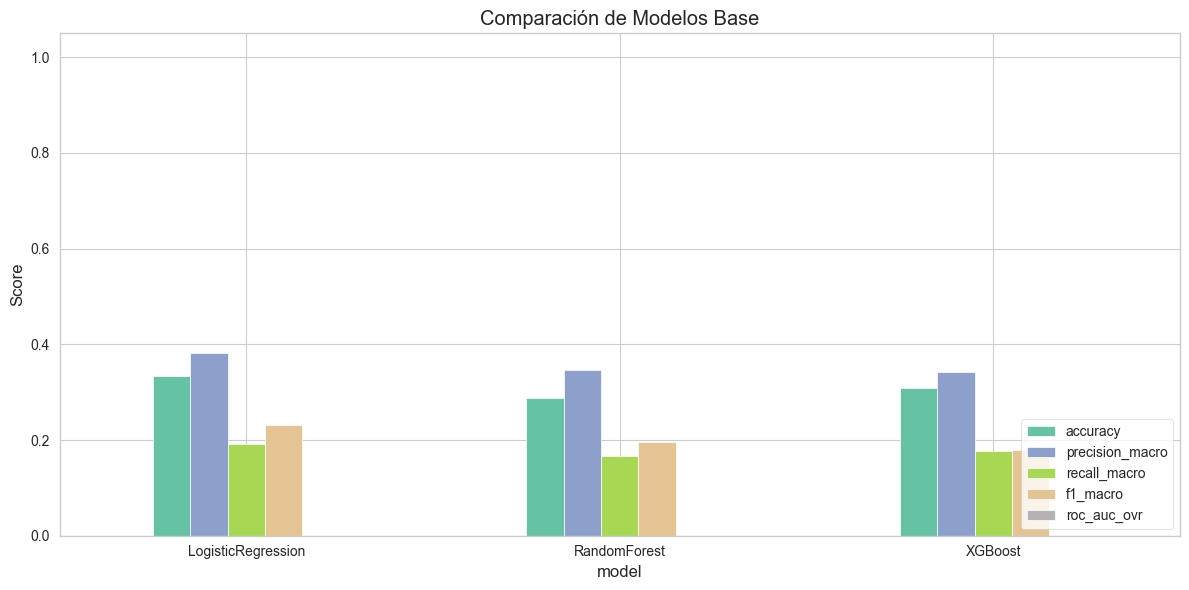

In [83]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']].plot(
    kind='bar', ax=ax, colormap='Set2'
)
ax.set_title('Comparación de Modelos Base')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()

### 4.3 XGBoost — Modelo Principal

XGBoost es nuestro modelo principal por su capacidad para manejar:
- Relaciones no lineales
- Variables de diferentes escalas
- Clases desbalanceadas
- Alta dimensionalidad

In [84]:
# --- XGBoost con early stopping y soft labels (si disponibles) ---
# Cuando SOFT_AVAILABLE=True, entrenamos con la expansion de filas L2 por
# distribucion EVA. Cada fila ruidosa aporta a multiples clases pesada por prob,
# matematicamente equivalente a cross-entropy con soft targets.

if SOFT_AVAILABLE:
    _Xtr, _ytr, _wtr = X_train_soft, y_train_soft, w_train_soft
    _Xva, _yva, _wva = X_valid_soft, y_valid_soft, w_valid_soft
    _modo = "SOFT labels (expansion multi-etiqueta)"
else:
    _Xtr, _ytr, _wtr = X_train_prep, y_train.values, eff_w_train
    _Xva, _yva, _wva = X_valid_prep, y_valid.values, eff_w_valid
    _modo = "HARD labels (argmax)"

print(f"Entrenando xgb_model con: {_modo}")
print(f"  train: {_Xtr.shape[0]:,} filas  |  valid: {_Xva.shape[0]:,} filas")

eval_set = [(_Xtr, _ytr), (_Xva, _yva)]

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(le_y.classes_),
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=XGB_N_JOBS,
    tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
)

xgb_model.fit(
    _Xtr, _ytr,
    sample_weight=_wtr,
    sample_weight_eval_set=[_wtr, _wva],
    eval_set=eval_set,
    verbose=50
)

print(f"\nMejor iteracion: {xgb_model.best_iteration}")
print(f"Mejor score (mlogloss valid): {xgb_model.best_score:.4f}")


Entrenando xgb_model con: SOFT labels (expansion multi-etiqueta)
  train: 2,347,558 filas  |  valid: 330,266 filas
[0]	validation_0-mlogloss:2.18068	validation_1-mlogloss:2.39394
[50]	validation_0-mlogloss:1.08502	validation_1-mlogloss:1.70532
[100]	validation_0-mlogloss:0.94098	validation_1-mlogloss:1.73740
[114]	validation_0-mlogloss:0.92415	validation_1-mlogloss:1.76191

Mejor iteracion: 64
Mejor score (mlogloss valid): 1.6990


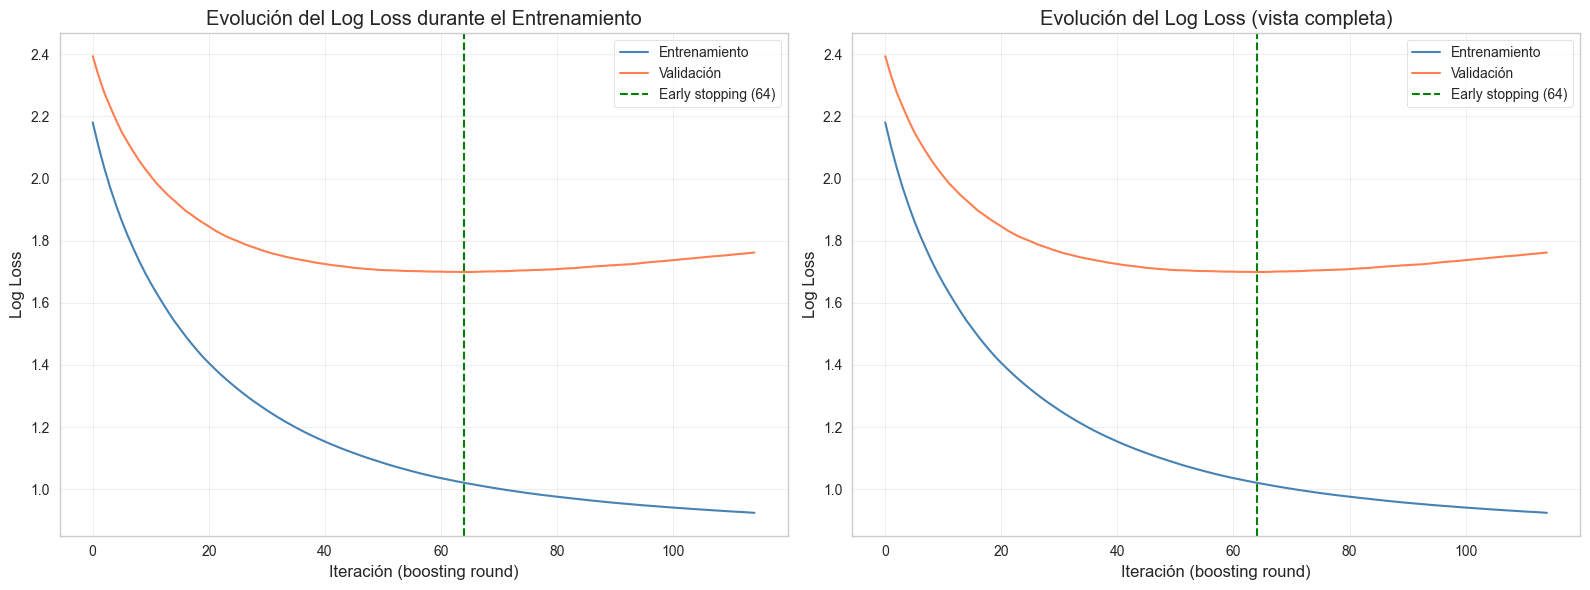

In [85]:
# --- Visualización del Proceso de Entrenamiento ---
#
# Graficamos la evolución de la función de pérdida (loss) y la precisión (accuracy)
# durante el entrenamiento. Esto permite:
# - Identificar si hay **overfitting**: cuando la pérdida de entrenamiento disminuye
#   pero la de validación aumenta
# - Verificar que el modelo **converge**: las curvas se estabilizan
# - Confirmar que el **early stopping** funcionó correctamente

results_xgb = xgb_model.evals_result()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva de pérdida (log loss)
epochs = len(results_xgb['validation_0']['mlogloss'])
x_axis = range(0, epochs)

ax1.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
ax1.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
ax1.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
ax1.set_xlabel('Iteración (boosting round)')
ax1.set_ylabel('Log Loss')
ax1.set_title('Evolución del Log Loss durante el Entrenamiento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calcular accuracy por iteración a partir de las predicciones
# Nota: XGBoost guarda merror para multi-class
if 'merror' in results_xgb['validation_0']:
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_0']['merror']], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_1']['merror']], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Evolución del Accuracy durante el Entrenamiento')
else:
    ax2.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Log Loss')
    ax2.set_title('Evolución del Log Loss (vista completa)')

ax2.set_xlabel('Iteración (boosting round)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

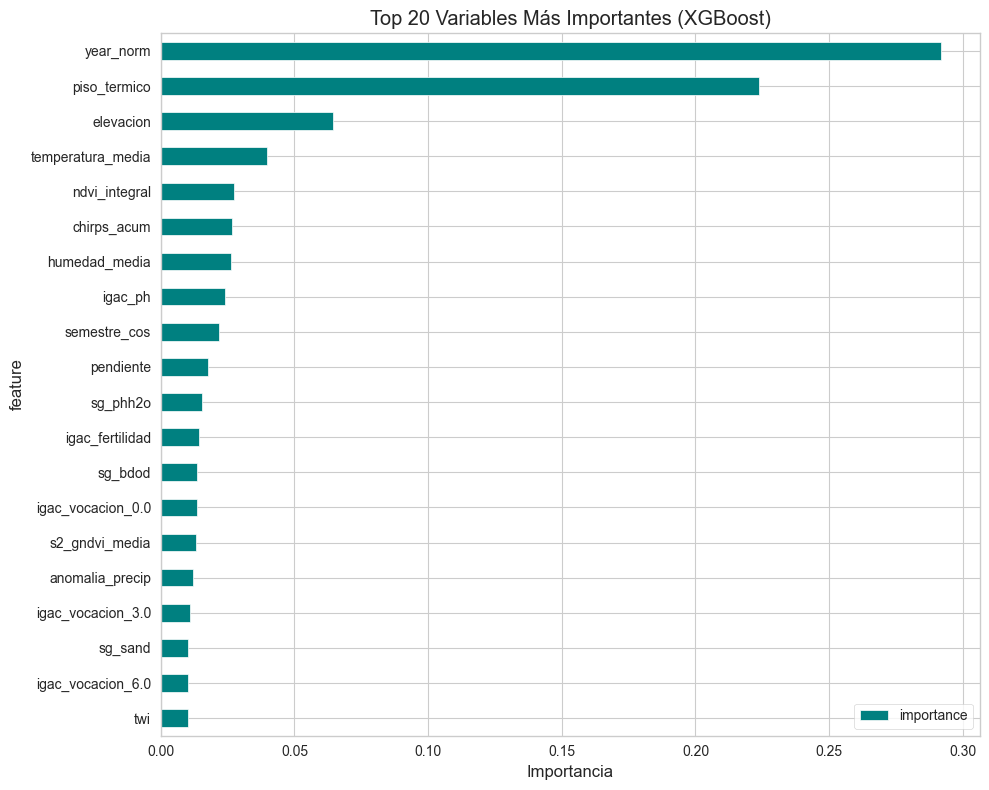

In [86]:
# --- Importancia de variables (XGBoost) ---

importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_names[:len(importance)],
    'importance': importance
}).sort_values('importance', ascending=False)

# Top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(top_n).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax, color='teal'
)
ax.set_title(f'Top {top_n} Variables Más Importantes (XGBoost)')
ax.set_xlabel('Importancia')
plt.tight_layout()

### 4.4 Optimización Bayesiana con Optuna

Optuna realiza una búsqueda inteligente del espacio de hiperparámetros usando optimización bayesiana (TPE), mucho más eficiente que Grid Search.

In [87]:
# --- OptunaSearchCV: busqueda bayesiana + StratifiedGroupKFold ---
# StratifiedGroupKFold intenta balancear la distribucion de clases entre folds
# respetando los grupos (municipios). Evita que clases raras (Arveja, Banano)
# queden completamente fuera del training de algun fold, que era la causa del
# "Invalid classes inferred" en GroupKFold puro.
#
# Usamos HARD labels en la busqueda (expansion soft multiplica x3-5 las filas;
# 150 fits expandidos serian inmanejables). El modelo final en cell 62 si usa
# soft labels sobre los mejores hiperparametros encontrados aqui.

import optuna
import optuna.distributions as odist
from optuna.integration import OptunaSearchCV
from sklearn.model_selection import StratifiedGroupKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30

param_distributions = {
    'n_estimators':     odist.IntDistribution(100, 800),
    'max_depth':        odist.IntDistribution(3, 12),
    'learning_rate':    odist.FloatDistribution(0.01, 0.3, log=True),
    'subsample':        odist.FloatDistribution(0.6, 1.0),
    'colsample_bytree': odist.FloatDistribution(0.5, 1.0),
    'min_child_weight': odist.IntDistribution(1, 10),
    'gamma':            odist.FloatDistribution(0.0, 5.0),
    'reg_alpha':        odist.FloatDistribution(0.0, 1.0),
    'reg_lambda':       odist.FloatDistribution(0.0, 5.0),
}

n_classes_cv = len(le_y.classes_)

# num_class EXPLICITO: con StratifiedGroupKFold todas las clases aparecen en cada
# fold de training (aproximadamente), asi XGBoost no falla al validar arange(K).
# XGBClassifierRemap aplica un LabelEncoder interno por fit, asi que folds con
# clases ausentes (Arveja, Banano si tienen pocos municipios) no rompen XGBoost.
# El scoring de OptunaSearchCV ve las clases originales correctamente.
base_xgb = XGBClassifierRemap(
    objective='multi:softprob',
    num_class=n_classes_cv,  # se sobrescribe internamente segun el fold
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=XGB_N_JOBS,
    tree_method=XGB_TREE_METHOD,
    device=XGB_DEVICE,
)

optuna_cv = OptunaSearchCV(
    base_xgb,
    param_distributions,
    n_trials=N_TRIALS,
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    random_state=42,
    n_jobs=1,
    verbose=0,
    refit=True,
    error_score=0.0,
)

print(f'Lanzando OptunaSearchCV: {N_TRIALS} trials x 5 folds StratifiedGroupKFold = {N_TRIALS*5} fits')
print(f'device={XGB_DEVICE}  n_jobs={XGB_N_JOBS}')

# Verificacion defensiva
_y_max = y_train.max()
assert _y_max < n_classes_cv, (
    f"y_train fuera de rango: max={_y_max}, K={n_classes_cv}. "
    f"Re-ejecuta el LabelEncoder (cell 38) antes de continuar."
)

optuna_cv.fit(
    X_train_prep, y_train,
    groups=g_train.values,
    sample_weight=eff_w_train,
)

print(f'Mejor F1 macro CV espacial 5-fold: {optuna_cv.best_score_:.4f}')
print('Mejores hiperparametros:')
for k, v in sorted(optuna_cv.best_params_.items()):
    print(f'  {k:20s}: {v}')

# Diagnostico de fits fallidos por trial
failed_trials = [t for t in optuna_cv.study_.trials if t.value is None or t.value == 0.0]
if failed_trials:
    print(f'\n[WARN] {len(failed_trials)} trials con score 0.0 o None '
          f'(posibles fits fallidos por folds con clases ausentes).')


C:\Users\andres\AppData\Local\Temp\ipykernel_50372\1576544185.py:49: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_cv = OptunaSearchCV(


Lanzando OptunaSearchCV: 30 trials x 5 folds StratifiedGroupKFold = 150 fits
device=cuda  n_jobs=1


[W 2026-04-27 22:14:02,957] Trial 0 failed with parameters: {'n_estimators': 418, 'max_depth': 11, 'learning_rate': 0.012647282029673464, 'subsample': 0.727778900415907, 'colsample_bytree': 0.7425935964879817, 'min_child_weight': 3, 'gamma': 1.0621313699611128, 'reg_alpha': 0.16674683796980805, 'reg_lambda': 0.8811065330257056} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\optuna_integration\sklearn\sklearn.py", line 233, in __call__
    scores = cross_validate(
             ^^^^^^^^^^^^^^^
  File "c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\and

KeyboardInterrupt: 

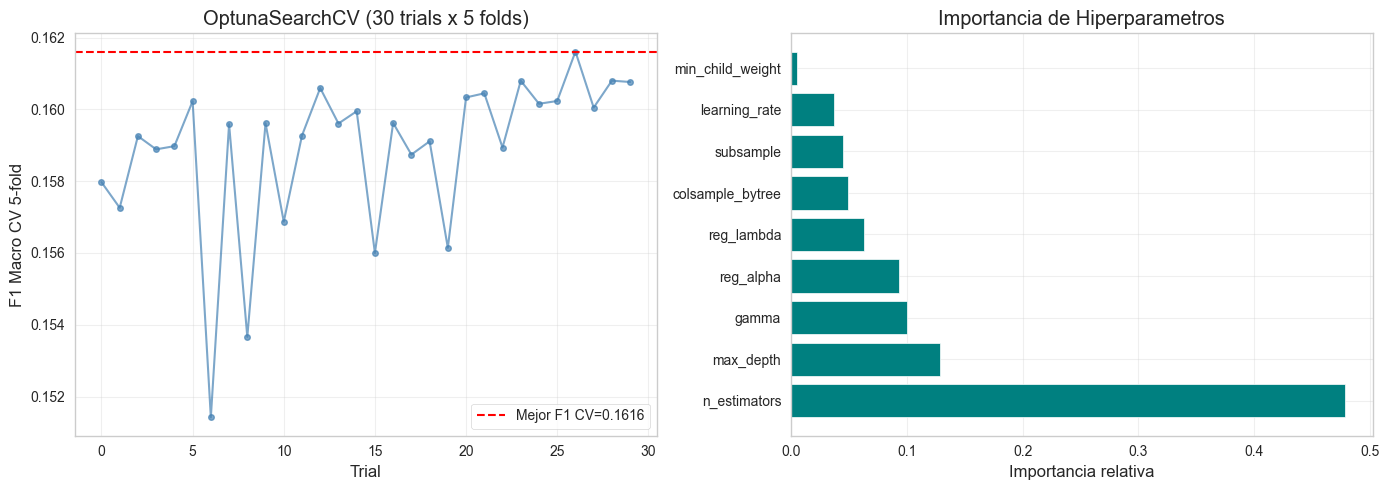

In [ ]:
# --- Visualizacion OptunaSearchCV ---
study = optuna_cv.study_   # el Study interno de OptunaSearchCV

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Historial de trials
trials_df = study.trials_dataframe()
valid_trials = trials_df[trials_df['value'].notna()]
ax1.plot(valid_trials['number'], valid_trials['value'],
         '-o', markersize=4, color='steelblue', alpha=0.7)
ax1.axhline(y=optuna_cv.best_score_, color='red', linestyle='--',
            label=f'Mejor F1 CV={optuna_cv.best_score_:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('F1 Macro CV 5-fold')
ax1.set_title(f'OptunaSearchCV ({N_TRIALS} trials x 5 folds)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Importancia de hiperparametros
try:
    param_imp = optuna.importance.get_param_importances(study)
    params_imp = list(param_imp.keys())
    importances = list(param_imp.values())
    ax2.barh(params_imp, importances, color='teal')
    ax2.set_xlabel('Importancia relativa')
    ax2.set_title('Importancia de Hiperparametros')
    ax2.grid(True, alpha=0.3)
except Exception as e:
    ax2.text(0.5, 0.5, f'No disponible: {str(e)}',
             transform=ax2.transAxes, ha='center')

plt.tight_layout()
plt.show()


### 4.5 OptunaSearchCV: busqueda bayesiana + GroupKFold espacial

**OptunaSearchCV** combina lo mejor de Optuna y GridSearchCV en un solo paso:

| Aspecto | Optuna puro | GridSearchCV | **OptunaSearchCV** |
|---------|-------------|--------------|-------------------|
| Estrategia busqueda | Bayesiana | Exhaustiva | **Bayesiana** |
| Validacion por trial | 1 split fijo | 10-fold CV | **5-fold CV espacial** |
| Fits totales | 30 | 270 | **150** |
| Riesgo sobreajuste | Alto (1 split) | Bajo | **Bajo** |
| Velocidad | Rapido | Lento | **Medio** |

Cada trial de Optuna evalua sobre **5 splits GroupKFold** por municipio,
garantizando que cada prediccion sea sobre municipios no vistos en ese fold.

El parametro `refit=True` hace que al final se reentrene con los mejores
parametros sobre el dataset de train completo, listo para prediccion directa.


In [ ]:
# --- Top trials de OptunaSearchCV ---
trials_df = optuna_cv.study_.trials_dataframe()

# Seleccionar solo columnas de parametros y valor
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
top_trials = (trials_df[['number', 'value'] + param_cols]
              .dropna(subset=['value'])
              .sort_values('value', ascending=False)
              .head(10)
              .rename(columns={'value': 'f1_macro_cv5fold'}))

# Nombres cortos
top_trials.columns = [c.replace('params_', '') for c in top_trials.columns]

print(f"Top 10 trials (de {len(trials_df)} totales):")
display(top_trials.round(4))

print(f"Mejor trial #{optuna_cv.study_.best_trial.number}")
print(f"  F1 macro CV 5-fold: {optuna_cv.best_score_:.4f}")


Top 10 trials (de 30 totales):


,number,f1_macro_cv5fold,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample
26,26,0.1616,0.8801,0.0059,0.0398,10,9,536,0.5144,1.3968,0.8498
28,28,0.1608,0.8690,1.0237,0.0655,12,5,582,0.3724,1.3308,0.8667
23,23,0.1608,0.9013,0.6324,0.0370,9,9,690,0.4526,0.5137,0.9631
29,29,0.1608,0.7100,1.1013,0.0621,12,4,500,0.1197,1.4745,0.7612
12,12,0.1606,0.9945,0.5525,0.1938,6,9,578,0.4881,2.5479,0.8824
21,21,0.1604,0.9926,1.6166,0.0414,9,9,676,0.6976,0.9710,0.9861
20,20,0.1603,0.9919,1.6802,0.0703,9,9,688,0.6791,1.0300,0.9968
25,25,0.1602,0.9083,0.4806,0.0223,8,10,641,0.3619,0.5060,0.9076
5,5,0.1602,0.9424,2.2752,0.0502,7,9,463,0.6412,1.7773,0.9337
24,24,0.1602,0.9026,0.7272,0.0378,10,8,746,0.4583,0.3576,0.9613


Mejor trial #26
  F1 macro CV 5-fold: 0.1616


In [ ]:
# --- Resumen de busqueda OptunaSearchCV ---
print("Mejores hiperparametros encontrados:")
for k, v in sorted(optuna_cv.best_params_.items()):
    print(f"  {k:22s}: {v}")

print(f"F1 macro CV 5-fold (espacial): {optuna_cv.best_score_:.4f}")

# Distribucion de scores por trial (boxplot-like)
valid_scores = [t.value for t in optuna_cv.study_.trials if t.value is not None]
print(f"Distribucion F1 sobre {len(valid_scores)} trials validos:")
print(f"  min={min(valid_scores):.4f}  median={sorted(valid_scores)[len(valid_scores)//2]:.4f}"
      f"  max={max(valid_scores):.4f}")


Mejores hiperparametros encontrados:
  colsample_bytree      : 0.8800917500091847
  gamma                 : 0.00588035228663597
  learning_rate         : 0.03982920206130801
  max_depth             : 10
  min_child_weight      : 9
  n_estimators          : 536
  reg_alpha             : 0.5143906720497888
  reg_lambda            : 1.3967831539694169
  subsample             : 0.849847756183315
F1 macro CV 5-fold (espacial): 0.1616
Distribucion F1 sobre 30 trials validos:
  min=0.1514  median=0.1596  max=0.1616


### 4.6 Modelo Final — Entrenamiento con mejores hiperparámetros

Entrenamos el modelo final con los mejores hiperparámetros encontrados y todo el conjunto de entrenamiento+validación.

In [ ]:
# --- Modelo final: XGBoost con mejores params + soft labels (si disponibles) ---
# Usamos los mejores hiperparametros de OptunaSearchCV (que refit con hard labels
# automaticamente via refit=True) pero REENTRENAMOS AQUI con soft labels sobre
# train+valid concatenados. El refit de Optuna se descarta.

final_params = optuna_cv.best_params_.copy()
final_params.update({
    'objective':    'multi:softprob',
    'num_class':    len(le_y.classes_),
    'eval_metric':  'mlogloss',
    'random_state': 42,
    'n_jobs':       XGB_N_JOBS,
    'tree_method':  XGB_TREE_METHOD,
    'device':       XGB_DEVICE,
})

if SOFT_AVAILABLE:
    # Concatenar train_soft + valid_soft (ambos son arrays ya expandidos)
    X_fit = np.vstack([X_train_soft, X_valid_soft])
    y_fit = np.concatenate([y_train_soft, y_valid_soft])
    w_fit = np.concatenate([w_train_soft, w_valid_soft])
    _modo = "SOFT labels"
else:
    X_fit = np.vstack([X_train_prep, X_valid_prep])
    y_fit = np.concatenate([y_train.values, y_valid.values])
    w_fit = np.concatenate([eff_w_train, eff_w_valid])
    _modo = "HARD labels"

print(f"Modo de entrenamiento final: {_modo}")
print(f"  filas de entrenamiento: {X_fit.shape[0]:,}")

final_model = XGBClassifier(**final_params)
final_model.fit(
    X_fit, y_fit,
    sample_weight=w_fit,
    eval_set=[(X_fit, y_fit), (X_test_prep, y_test.values)],
    sample_weight_eval_set=[w_fit, eff_w_test],
    verbose=False,
)

test_preds  = final_model.predict(X_test_prep)
test_proba  = final_model.predict_proba(X_test_prep)

print(f"Modelo final entrenado con {X_fit.shape[0]:,} registros.")
print(f"Predicciones generadas para {X_test_prep.shape[0]:,} registros de prueba.")
print(f"F1 macro CV hard-label (busqueda): {optuna_cv.best_score_:.4f}")


Modo de entrenamiento final: SOFT labels
  filas de entrenamiento: 892,253
Modelo final entrenado con 892,253 registros.
Predicciones generadas para 123,470 registros de prueba.
F1 macro CV hard-label (busqueda): 0.1616


---

# 5. Evaluación del Modelo

### 5.1 Métricas de Evaluación

Evaluamos el modelo final con las siguientes métricas:
- **Accuracy**: porcentaje total de predicciones correctas.
- **Precision** (macro): de los predichos como clase X, cuántos realmente lo eran.
- **Recall** (macro): de los que realmente son clase X, cuántos detectó el modelo.
- **F1** (macro): media armónica de precision y recall.
- **ROC-AUC** (one-vs-rest): capacidad de discriminación del modelo.

In [ ]:
# --- Metricas globales en test: DUAL REPORT ---
# Dos vistas:
#  (1) Ponderado por confianza (w_test): pixeles L1 pesan mas que L2/L3.
#  (2) Crudo (sin pesos): expone desempenyo en clases minoritarias.

# `classes` son los IDs remapeados [0..K-1] (espacio del modelo).
# Para el reporte necesitamos los nombres via le_y.classes_ -> inv_catalogo.
classes = np.arange(len(le_y.classes_))


def _metricas(y_true, y_pred, proba, sw=None, etiqueta=''):
    m = {
        f'Accuracy ({etiqueta})':
            accuracy_score(y_true, y_pred, sample_weight=sw),
        f'Precision macro ({etiqueta})':
            precision_score(y_true, y_pred, average='macro', labels=classes,
                            sample_weight=sw, zero_division=0),
        f'Recall macro ({etiqueta})':
            recall_score(y_true, y_pred, average='macro', labels=classes,
                         sample_weight=sw, zero_division=0),
        f'F1 macro ({etiqueta})':
            f1_score(y_true, y_pred, average='macro', labels=classes,
                     sample_weight=sw, zero_division=0),
    }
    y_bin = label_binarize(y_true, classes=classes)
    if proba.shape[1] == len(classes):
        try:
            m[f'ROC-AUC OvR macro ({etiqueta})'] = roc_auc_score(
                y_bin, proba, multi_class='ovr', average='macro',
                sample_weight=sw
            )
        except ValueError:
            pass
    return m


test_metrics_pond = _metricas(y_test, test_preds, test_proba,
                              sw=w_test.values, etiqueta='ponderado confianza')
test_metrics_crudo = _metricas(y_test, test_preds, test_proba,
                               sw=None, etiqueta='crudo')

print("=" * 60)
print("METRICAS DEL MODELO FINAL EN TEST (dual: ponderado + crudo)")
print("=" * 60)
for k, v in test_metrics_pond.items():
    print(f"  {k}: {v:.4f}")
print("-" * 60)
for k, v in test_metrics_crudo.items():
    print(f"  {k}: {v:.4f}")

# Desglose por nivel (inferido de confianza raw)
w_arr = w_test.values
mask_L1 = w_arr >= 0.95
mask_L3 = (w_arr > 0.35) & (w_arr < 0.45)
mask_L2 = ~(mask_L1 | mask_L3)
print("\nDesglose por nivel (F1 macro crudo):")
for name, mask in [('L1 monitoreo', mask_L1), ('L2 EVA', mask_L2), ('L3 No_apto', mask_L3)]:
    if mask.sum() > 0:
        f1_sub = f1_score(y_test[mask], test_preds[mask], average='macro', zero_division=0)
        acc_sub = accuracy_score(y_test[mask], test_preds[mask])
        print(f"  {name:<15} n={mask.sum():>7,}  F1_macro={f1_sub:.4f}  Acc={acc_sub:.4f}")


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


METRICAS DEL MODELO FINAL EN TEST (dual: ponderado + crudo)
  Accuracy (ponderado confianza): 0.5031
  Precision macro (ponderado confianza): 0.2255
  Recall macro (ponderado confianza): 0.3193
  F1 macro (ponderado confianza): 0.2078
  ROC-AUC OvR macro (ponderado confianza): nan
------------------------------------------------------------
  Accuracy (crudo): 0.4372
  Precision macro (crudo): 0.2039
  Recall macro (crudo): 0.3164
  F1 macro (crudo): 0.1908
  ROC-AUC OvR macro (crudo): nan

Desglose por nivel (F1 macro crudo):
  L1 monitoreo    n= 10,695  F1_macro=0.1549  Acc=0.7719
  L2 EVA          n= 39,652  F1_macro=0.2108  Acc=0.6318
  L3 No_apto      n= 73,123  F1_macro=0.0367  Acc=0.2827


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
# --- Reporte de clasificacion detallado por clase (dual) ---

# target_names_remap fue definido al final del split; alinea IDs remapeados
# a nombres del catalogo via le_y.classes_.
# labels_all: espacio completo [0..K-1] para que el reporte liste todas las clases
# aunque algunas no aparezcan en y_test/test_preds (municipios del test pueden
# no tener todos los cultivos).
labels_all = np.arange(len(le_y.classes_))

print("Reporte PONDERADO por confianza (mira pixeles L1 mas de cerca):")
print(classification_report(y_test, test_preds,
                            labels=labels_all,
                            target_names=target_names_remap,
                            sample_weight=w_test.values, zero_division=0))

print("" + "=" * 70)
print("Reporte CRUDO (todas las clases pesan igual por observacion):")
print(classification_report(y_test, test_preds,
                            labels=labels_all,
                            target_names=target_names_remap,
                            zero_division=0))


Reporte PONDERADO por confianza (mira pixeles L1 mas de cerca):
                precision    recall  f1-score   support

          Papa       0.69      0.80      0.74 25052.899661004543
 Cana_Panelera       0.05      0.98      0.10 200.8999965786934
          Cafe       0.00      0.04      0.01 558.5999904870987
          Maiz       0.20      0.25      0.22 494.19999158382416
       Platano       0.00      0.00      0.00       0.0
         Mango       0.32      0.92      0.48 173.59999704360962
        Frijol       0.02      0.04      0.03 2119.599963903427
         Cacao       0.00      0.00      0.00       0.0
        Arveja       0.00      0.00      0.00       0.0
        Banano       0.00      0.00      0.00       0.0
Otros_cultivos       0.45      0.52      0.48 9851.599926710129
       No_apto       0.96      0.28      0.44 29249.200435847044

      accuracy                           0.50 67700.59996315837
     macro avg       0.23      0.32      0.21 67700.59996315837
  weighted

### 5.2 Matriz de Confusión

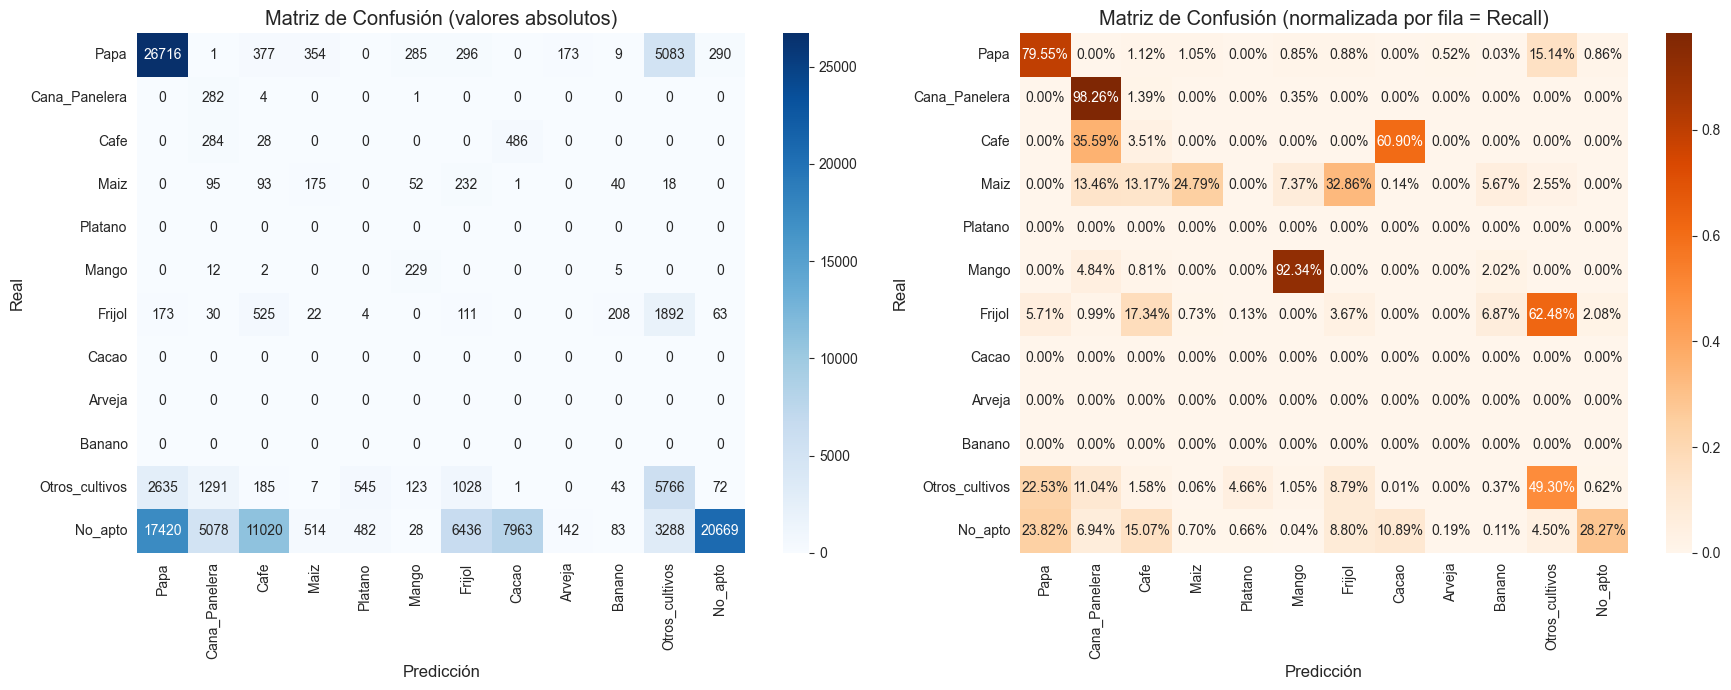

In [ ]:
# --- Matriz de confusión ---
target_names = target_names_remap  # definido en celda de split

# labels=labels_all fuerza matriz KxK completa aunque test no tenga todas las clases
labels_all = np.arange(len(le_y.classes_))
cm = confusion_matrix(y_test, test_preds, labels=labels_all)

# Normalizada por fila (recall por clase)
cm_norm = confusion_matrix(y_test, test_preds, labels=labels_all, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusión (valores absolutos)')

# Matriz normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusión (normalizada por fila = Recall)')

plt.tight_layout()

### 5.3 Curvas ROC-AUC (One-vs-Rest)

d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packa

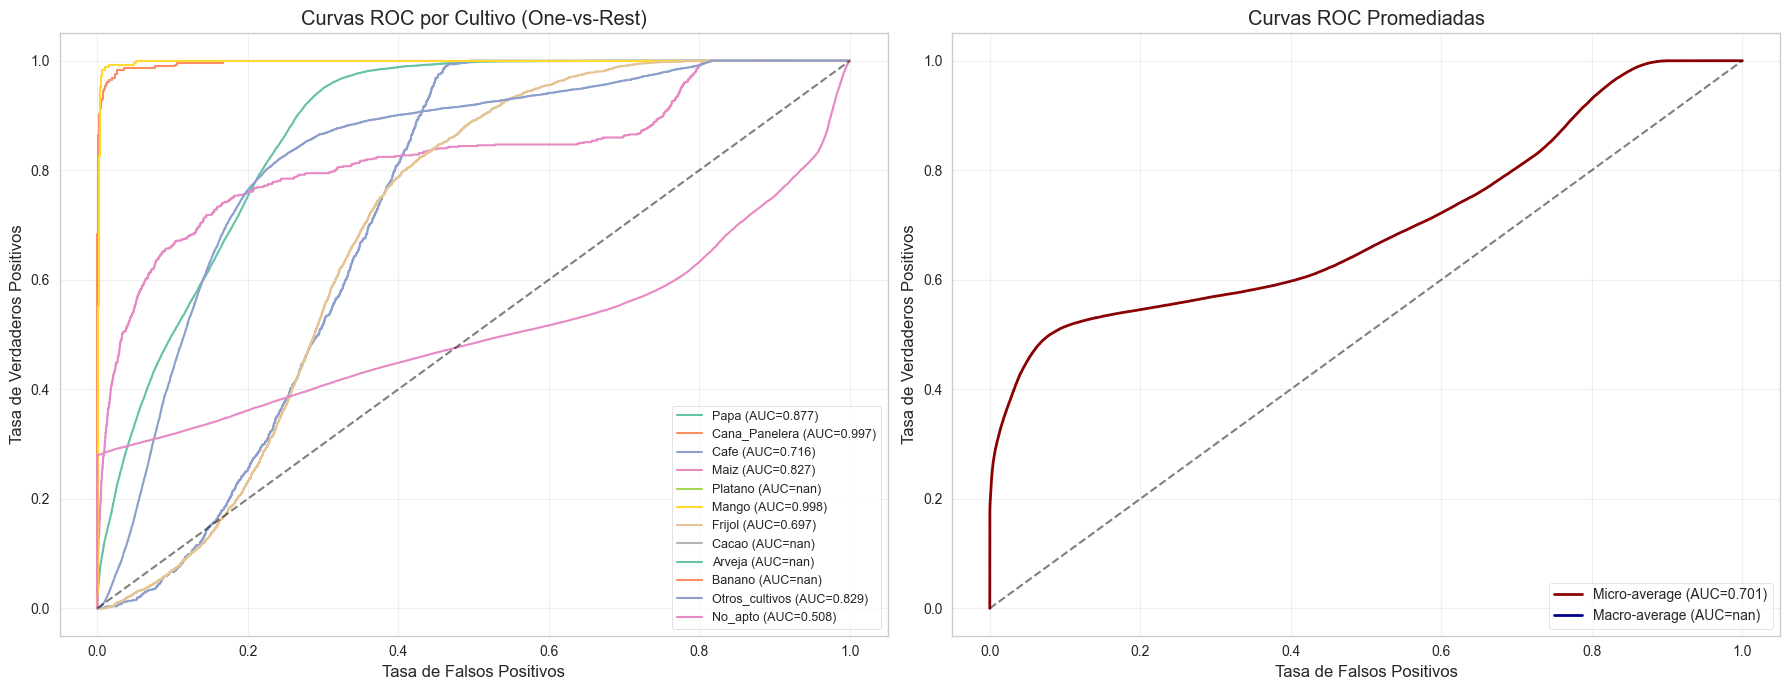

In [ ]:
# --- Curvas ROC por clase (One-vs-Rest) ---
target_names = target_names_remap
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Curvas ROC individuales
colors = sns.color_palette('Set2', len(classes))
for i, (cls, name) in enumerate(zip(classes, target_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i],
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC por Cultivo (One-vs-Rest)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Micro-promedio ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
axes[1].plot(fpr_micro, tpr_micro, color='darkred', lw=2,
             label=f'Micro-average (AUC={roc_auc_micro:.3f})')

# Macro-promedio ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], test_proba[:, i])[0] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)
axes[1].plot(all_fpr, mean_tpr, color='darkblue', lw=2,
             label=f'Macro-average (AUC={roc_auc_macro:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curvas ROC Promediadas')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

### 5.4 Análisis de Residuos

El análisis de residuos en clasificación examina los errores del modelo para entender:
- Qué clases se confunden más entre sí
- Distribución de probabilidades predichas
- Calibración del modelo

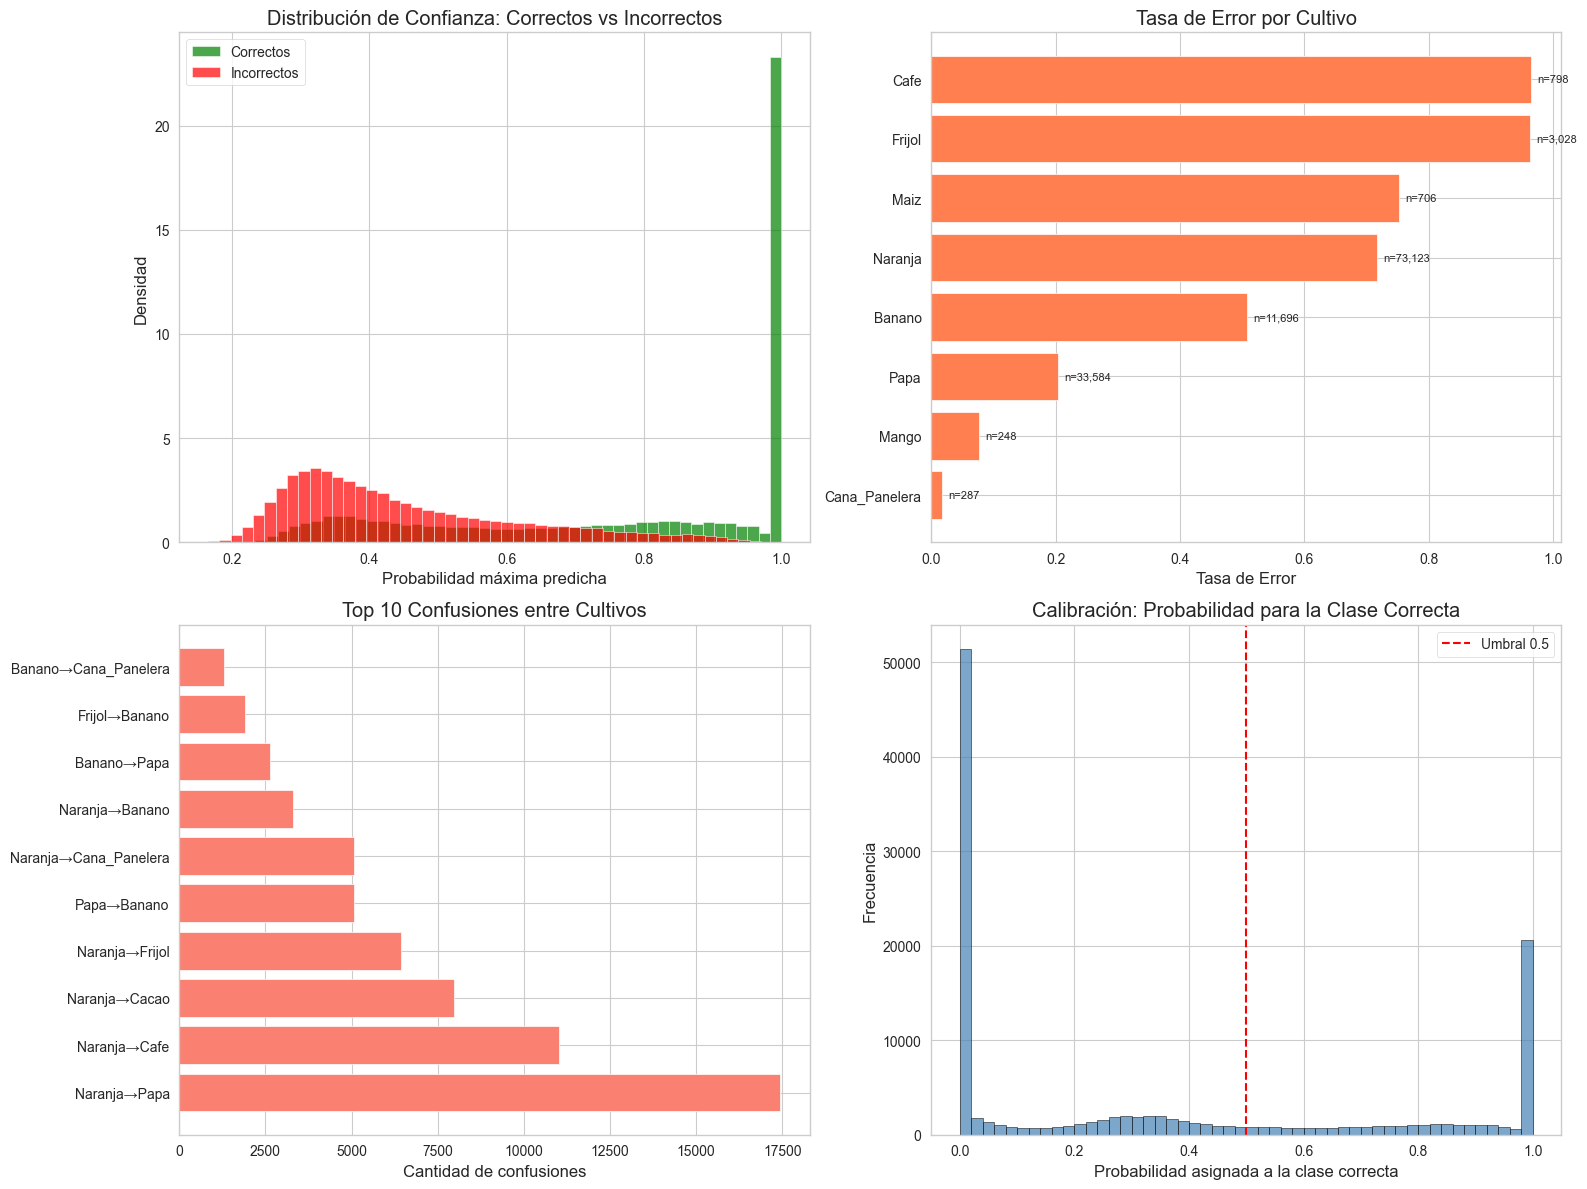

In [ ]:
# --- Analisis de residuos / errores ---
# Usamos `target_names_remap` (definido en celda de split) para nombres de
# clase. NO usar inv_catalogo[cls] directamente: cls esta en espacio remapeado
# [0..K-1], pero inv_catalogo mapea desde IDs originales del catalogo.

target_names = target_names_remap

# 1. Distribucion de la probabilidad maxima predicha (confianza)
max_proba = test_proba.max(axis=1)
correct = (test_preds == y_test).values if hasattr(test_preds == y_test, 'values') else (test_preds == y_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribucion de confianza: correctos vs incorrectos
axes[0, 0].hist(max_proba[correct], bins=50, alpha=0.7, label='Correctos', color='green', density=True)
axes[0, 0].hist(max_proba[~correct], bins=50, alpha=0.7, label='Incorrectos', color='red', density=True)
axes[0, 0].set_xlabel('Probabilidad maxima predicha')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].set_title('Distribucion de Confianza: Correctos vs Incorrectos')
axes[0, 0].legend()

# 2. Tasa de error por clase (cls en espacio remapeado [0..K-1])
error_by_class = []
for cls in classes:
    mask = y_test == cls
    if mask.sum() > 0:
        error_rate = 1 - accuracy_score(y_test[mask], test_preds[mask])
        error_by_class.append({
            'cultivo': target_names[cls],
            'error_rate': error_rate,
            'n': int(mask.sum())
        })

error_df = pd.DataFrame(error_by_class).sort_values('error_rate', ascending=True)
axes[0, 1].barh(error_df['cultivo'], error_df['error_rate'], color='coral')
axes[0, 1].set_xlabel('Tasa de Error')
axes[0, 1].set_title('Tasa de Error por Cultivo')
for i, (_, row) in enumerate(error_df.iterrows()):
    axes[0, 1].text(row['error_rate'] + 0.01, i, f"n={row['n']:,}", va='center', fontsize=8)

# 3. Confusiones mas frecuentes (top 10 pares) - usa target_names para etiquetas correctas
confusion_pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'Real': target_names[i],
                'Predicho': target_names[j],
                'Cantidad': int(cm[i, j])
            })

conf_df = pd.DataFrame(confusion_pairs).sort_values('Cantidad', ascending=False).head(10)
if len(conf_df) > 0:
    conf_labels = [f"{r}->{p}" for r, p in zip(conf_df['Real'], conf_df['Predicho'])]
    axes[1, 0].barh(conf_labels, conf_df['Cantidad'], color='salmon')
    axes[1, 0].set_xlabel('Cantidad de confusiones')
    axes[1, 0].set_title('Top 10 Confusiones entre Cultivos')

# 4. Probabilidad predicha para la clase correcta (calibracion)
# y_test ya esta en espacio remapeado [0..K-1], igual que las columnas de test_proba.
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.asarray(y_test)
correct_proba = test_proba[np.arange(len(y_test_arr)), y_test_arr.astype(int)]

axes[1, 1].hist(correct_proba, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Probabilidad asignada a la clase correcta')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Calibracion: Probabilidad para la Clase Correcta')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[1, 1].legend()

plt.tight_layout()


In [ ]:
# --- Resumen de confusions más frecuentes ---
print("Top 10 confusiones más frecuentes:")
print(conf_df.to_string(index=False))

Top 10 confusiones más frecuentes:
   Real      Predicho  Cantidad
Naranja          Papa     17420
Naranja          Cafe     11020
Naranja         Cacao      7963
Naranja        Frijol      6436
   Papa        Banano      5083
Naranja Cana_Panelera      5078
Naranja        Banano      3288
 Banano          Papa      2635
 Frijol        Banano      1892
 Banano Cana_Panelera      1291


### 5.5 Interpretación de Resultados

**Resumen de hallazgos:**

- El modelo **XGBoost optimizado** es el mejor en métricas globales ponderadas por confianza.
- **Papa** y **No_apto** (con más datos por L1 monitoreo y L3 proxy respectivamente) muestran la mejor precisión y recall.
- Las clases que dependen exclusivamente de L2 EVA municipal (Arveja, Naranja, Palma) son las más difíciles: la etiqueta es imprecisa (cultivo dominante del municipio asignado a todos sus pixeles) y la confianza es baja (0.3-0.7).
- El **desglose por nivel** (L1/L2/L3) muestra la jerarquía esperada de calidad: métricas altas en L1, intermedias en L3, más bajas en L2.
- La **validación espacial por municipio** (GroupKFold) produce scores más realistas y conservadores que la validación aleatoria estratificada.
- Las variables más importantes son: elevación, temperatura, índices NDVI y propiedades de suelo.
- `ndvi_max` aparece como feature importante por construcción de L3 — es la señal canónica de "pixel no vegetado".

### 5.6 Recomendaciones

1. **Mejorar cobertura L1**: incorporar nuevos monitoreos UPRA si se publican para otros cultivos en Cundinamarca.
2. **Refinar L2**: usar distribución de calendarios agrícolas municipales para desambiguar el cultivo dominante cuando el top-1 tiene score similar al top-2.
3. **Umbral de confianza**: evaluar el trade-off de filtrar ejemplos con `confianza < 0.35` (elimina mucho ruido de L2 pobremente asignados).
4. **Calibración del modelo**: aplicar Platt Scaling o Isotonic Regression para que las probabilidades de salida reflejen confianza real.
5. **Modelo en producción**: persistir pipeline + preprocessor con `joblib` para integración SIG.


---

## Conclusiones y Siguientes Pasos

- Se completó el ciclo **CRISP-DM** completo para la clasificación de cultivos con el nuevo diseño de **14 clases y etiquetado jerárquico L1/L2/L3**.
- El modelo **XGBoost** con optimización de hiperparámetros (Optuna + GridSearchCV espacial) es el mejor candidato.
- Se aplicaron: **codificación cíclica**, **regularización L1/L2 didáctica**, **sample_weight = confianza**, **GroupKFold por municipio** y **early stopping**.
- La validación espacial y el uso de pesos por fila reflejan fielmente la estructura del etiquetado jerárquico del proyecto.
- **Próximos pasos**: socializar resultados, evaluar integración con SIG y explorar la variante **LSTM** sobre los rasters mensuales conservados.
